# TP de Regresión — Predicción de precios de casas
### Aprendizaje Automático 1 — Tecnicatura en Inteligencia Artificial (FCEIA - UNR)

**Integrantes:** Aguirre, Gambande, Paladini



# Consigna 3:

---
## 3.1 Configuración del entorno y carga de datos

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización (consistencia entre gráficos)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42  # semilla fija para reproducibilidad

In [2]:
# Carga del dataset
df = pd.read_csv('data/house-prices-tp.csv') 

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


---
## 3.2 Inspección del dataset

In [3]:
# Tipos de datos y nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


El dataset tiene 556 filas y 14 columnas, todas numéricas (float64), con valores faltantes en todas ellas, que se analizan en 3.4. CHAS es una dummy que se trata como categórica.

In [4]:
# Separación de variables por tipo
# CHAS es una dummy, hay que tratarla como categórica

cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_numericas.remove('MEDV')  # varaible target se analiza aparte
col_categorica = 'CHAS'
if col_categorica in cols_numericas:
    cols_numericas.remove(col_categorica)

print(f'Variables numéricas continuas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variable categórica (dummy): {col_categorica}')
print('Variable target: MEDV')

Variables numéricas continuas (12): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Variable categórica (dummy): CHAS
Variable target: MEDV


---
## 3.3 Análisis descriptivo

Medidas de tendencia central, dispersión, sesgo y curtosis para cada variable numérica.

- Esto permite entender rango de variación y forma de la distribución de cada variable antes de decidir
transformaciones o tratamiento de outliers.

In [5]:
desc = df[cols_numericas + ['MEDV']].describe().T
# el .T transpone la tabla para ver una fila por variable con sus datos estadisticos


desc['sesgo'] = df[cols_numericas + ['MEDV']].skew()
# Mide qué tan asimétrica es la distribución de cada variable: 
# 0 = simétrica, positivo = cola hacia la derecha, negativo = cola hacia la izquierda

desc['curtosis'] = df[cols_numericas + ['MEDV']].kurtosis()
# Mide qué tan pesadas son las colas de la distribución comparado con una normal
# curtosis cerca de cero: mesocúrtica
# valores altos indican más outliers/valores extremos: leptocúrtica (colas pesadas, pico mas pronunciado).
# valores bajos indican una distribución más achatada: platicúrtica (colas livianas, distribucion mas aplanada).

desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'sesgo', 'curtosis']]

,mean,std,min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.845517,13.828631,0.00632,0.08447,0.315330,4.871410,88.9762,3.746677,15.248736
ZN,13.197175,24.902981,0.00000,0.00000,0.000000,20.000000,100.0000,1.957797,2.749832
INDUS,11.218725,6.942021,0.46000,5.13000,9.690000,18.100000,27.7400,0.301523,-1.206425
NOX,0.560050,0.119472,0.38500,0.45300,0.538000,0.643986,0.8710,0.694358,-0.229572
RM,6.291839,0.782403,3.56100,5.87550,6.208000,6.638500,8.7800,0.373812,1.555062
AGE,67.632303,28.461925,2.90000,42.27500,76.500000,93.825000,100.0000,-0.550692,-1.038192
DIS,3.944102,2.255689,1.12960,2.11210,3.340107,5.400700,12.1265,1.078906,0.705364
RAD,9.699379,8.684495,1.00000,4.00000,5.000000,23.632660,24.0000,0.951478,-0.947840
TAX,409.575089,167.689379,187.00000,279.00000,335.000000,666.000000,711.0000,0.632306,-1.170504
PTRATIO,18.429904,2.194759,12.60000,17.00000,19.000000,20.200000,22.0000,-0.787238,-0.304842


### Criterio de interpretación

Para clasificar el sesgo y la curtosis se toma como referencia el criterio utilizado en el material de análisis exploratorio provisto por la cátedra. 

- El **sesgo** de una distribución se considera aproximadamente simétrica cuando |sesgo| < 0.5, cuando 0.5 ≤ |sesgo| < 1 presenta asimetría moderada y cuando |sesgo| ≥ 1 presenta asimetría alta. 

- La asimetría es positiva (cola hacia la derecha) si el sesgo es mayor que 0 y negativa (cola hacia la izquierda) si es menor que 0. 

- La **curtosis** se considera mesocúrtica cuando |curtosis| < 0.5, leptocúrtica (colas pesadas) cuando la curtosis es positiva y supera ese umbral, y platicúrtica (colas livianas, distribución achatada) cuando es negativa y supera 0.5.

In [6]:
# Variables con sesgo alto (|sesgo| >= 1) y curtosis alta (> 0.5), ordenadas por curtosis
variables = cols_numericas + ['MEDV']
resumen = pd.DataFrame({'sesgo': df[variables].skew(), 'curtosis': df[variables].kurtosis()})

extremas = resumen[(resumen['sesgo'].abs() >= 1) & (resumen['curtosis'] > 0.5)]
extremas.sort_values('curtosis', ascending=False).round(2)

,sesgo,curtosis
CRIM,3.75,15.25
B,-2.40,4.50
ZN,1.96,2.75
MEDV,1.06,1.17
DIS,1.08,0.71


Las variables CRIM, B, ZN, DIS y MEDV presentan sesgo alto (|sesgo| ≥ 1), como muestra la tabla anterior. CRIM y B son las más extremas:

- **CRIM** tiene cola derecha muy larga y una curtosis muy elevada (15.25, leptocúrtica), lo que indica una distribución con colas muy pesadas.

- **B** presenta un sesgo negativo fuerte (-2.40) y una curtosis alta (4.50, leptocúrtica).

- CRIM y DIS, con sesgo positivo alto, son candidatas a una **transformación logarítmica** antes de entrenar el modelo de regresión, ya que la regresión lineal asume relaciones lineales y errores homocedásticos, y una distribución muy sesgada puede violar esos supuestos. ZN también tiene sesgo positivo, pero cerca del 70% de sus valores son 0, por lo que el logaritmo mejoraría poco. B tiene sesgo negativo y el logaritmo lo empeoraría, por lo que se deja sin transformar.

- MEDV, al ser el target, también sugiere evaluar una transformación logarítmica, aunque complica la interpretación.

Luego de realizar una descripción sobre cada variable mediante estadísticas descriptivas, procedemos a analizar cada una de las variables involucradas detallando características, comportamiento y rango de variación de las mismas.

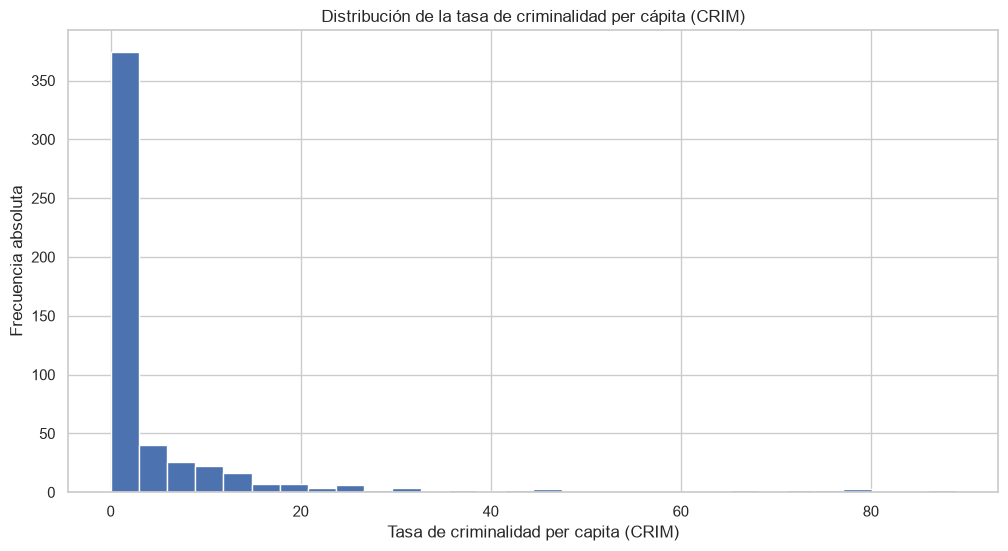

In [7]:
plt.hist(df["CRIM"], bins=30)
plt.title("Distribución de la tasa de criminalidad per cápita (CRIM)")
plt.ylabel("Frecuencia absoluta")
plt.xlabel("Tasa de criminalidad per capita (CRIM)")
plt.show()

La variable **CRIM** (tasa de criminalidad per cápita por ciudad) presenta valores entre 0.006 y 88.976, con una media de aproximadamente 5.845 y una desviación estándar de 13.829, casi tres veces la media, lo que muestra una dispersión muy alta. 

La mediana (0.315) es muy inferior a la media, y el 75% de las observaciones tiene una tasa menor a 4.871, por lo que la gran mayoría se concentra en valores bajos mientras que unos pocos casos extremos llegan hasta casi 89. 

Esto se refleja en un sesgo positivo alto (3.747), que indica una distribución asimétrica con cola hacia la derecha, y en un exceso de curtosis muy elevado (15.249), propio de una distribución leptocúrtica con colas muy pesadas.

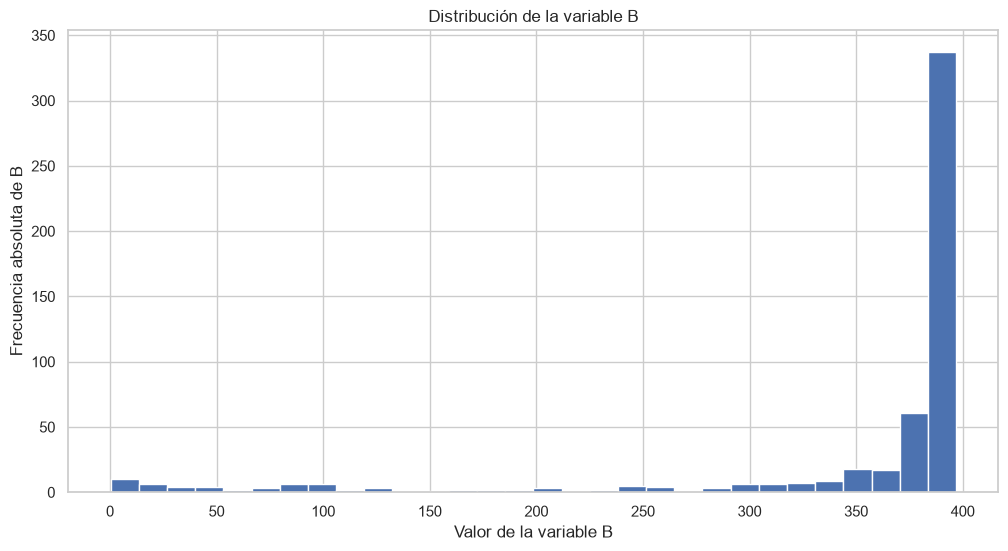

In [8]:
plt.hist(df["B"], bins=30)
plt.title("Distribución de la variable B")
plt.ylabel("Frecuencia absoluta de B")
plt.xlabel("Valor de la variable B")
plt.show()

La variable **B** se define como 1000(Bk - 0.63)², donde Bk es la proporción de población negra por ciudad, y presenta valores entre 0.32 y 396.9. Su media es de aproximadamente 347.81 y su desviación estándar de 99.64, mientras que la mediana (390.82) es notablemente mayor que la media: cerca del 66% de las observaciones no nulas supera 380 y el 22.7% (121 observaciones) toma exactamente el valor máximo 396.9. Esto se refleja en un sesgo negativo alto (-2.40), que indica una distribución fuertemente asimétrica con cola hacia la izquierda, y en un exceso de curtosis elevado (4.50), propio de una distribución leptocúrtica con colas pesadas.

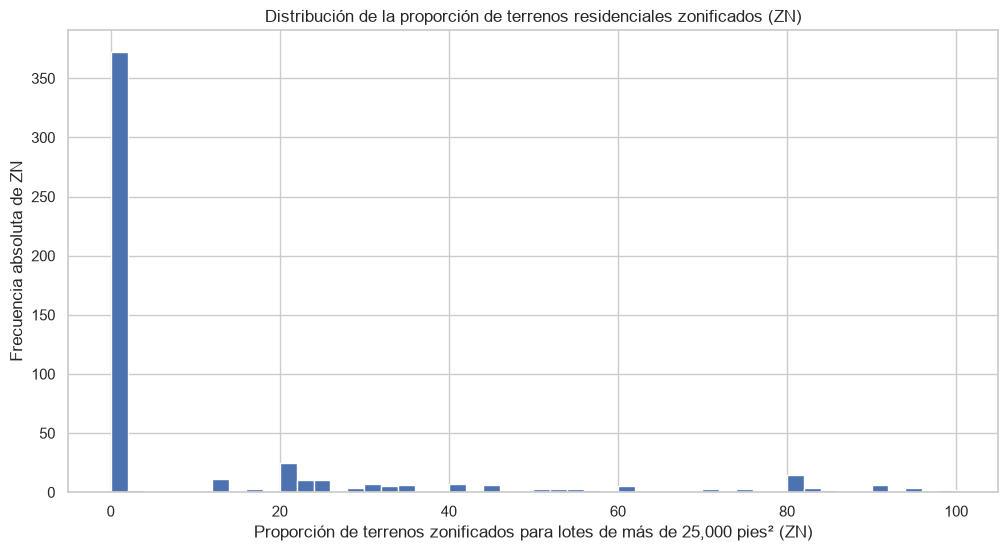

In [9]:
plt.hist(df["ZN"], bins=50)
plt.title("Distribución de la proporción de terrenos residenciales zonificados (ZN)")
plt.ylabel("Frecuencia absoluta de ZN")
plt.xlabel("Proporción de terrenos zonificados para lotes de más de 25,000 pies² (ZN)")
plt.show()

La variable **ZN** (proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies cuadrados) presenta valores entre 0 y 100, con una media de aproximadamente 13.197 y una desviación estándar de 24.903, casi el doble de la media, lo que indica una dispersión muy alta. En el histograma se observa una fuerte concentración en 0: Q1 y la mediana (Q2) valen 0, el tercer cuartil es 20 y cerca del 70% de las observaciones no nulas son exactamente 0, es decir, zonas sin terrenos residenciales grandes. Esto genera un sesgo positivo alto (1.958), que indica una distribución asimétrica con cola hacia la derecha, y un exceso de curtosis de 2.750, propio de una distribución leptocúrtica con colas pesadas.

In [10]:
# cantidad y porcentaje de observaciones iguales a 0
n_ceros = (df["ZN"] == 0).sum()
n_validos = df["ZN"].count()
print(f"ZN = 0: {n_ceros} de {n_validos} observaciones no nulas ({n_ceros / n_validos * 100:.1f}%)")

ZN = 0: 372 de 534 observaciones no nulas (69.7%)


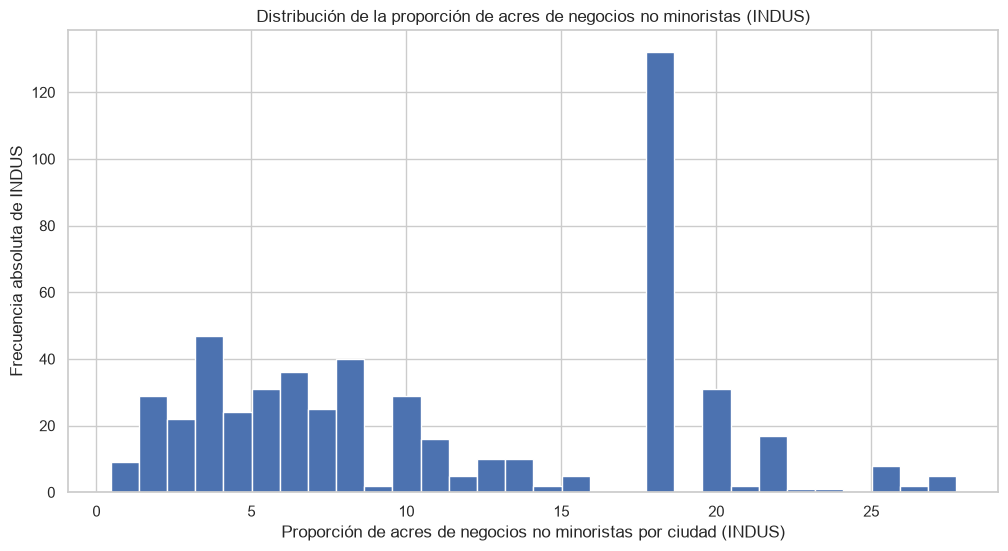

In [11]:
plt.hist(df["INDUS"], bins=30)
plt.title("Distribución de la proporción de acres de negocios no minoristas (INDUS)")
plt.ylabel("Frecuencia absoluta de INDUS")
plt.xlabel("Proporción de acres de negocios no minoristas por ciudad (INDUS)")
plt.show()

La variable **INDUS** (proporción de acres de negocios no minoristas por ciudad) presenta valores entre 0.46 y 27.74, con una media de aproximadamente 11.22 y una mediana de 9.69. La desviación estándar es de aproximadamente 6.94, lo que indica una dispersión moderada. Su sesgo es de aproximadamente 0.30, por lo que puede considerarse aproximadamente simétrica, aunque la media algo mayor que la mediana refleja una leve cola hacia la derecha. Su curtosis es de aproximadamente -1.21, lo que indica una distribución platicúrtica, más achatada y con colas más livianas que una distribución normal. Además, cerca del 24% de las observaciones toma exactamente el valor 18.1, lo que genera un pico aislado en el histograma y coincide con que el tercer cuartil también valga 18.1.

In [12]:
# Distribución de la variable dummy CHAS: cantidad y porcentaje (incluye nulos)
pd.DataFrame({
    'Cantidad': df["CHAS"].value_counts(dropna=False),
    'Porcentaje (%)': df["CHAS"].value_counts(normalize=True, dropna=False).mul(100).round(2)})

,Cantidad,Porcentaje (%)
CHAS,,
0.0,485,87.23
1.0,48,8.63
NaN,23,4.14


La variable **CHAS** (variable dummy del río Charles) indica si el tramo limita con el río: toma el valor 1 si limita y 0 en caso contrario. Del total de observaciones, el 87.23% (485 filas) no limita con el río, el 8.63% (48 filas) sí limita y el 4.14% (23 filas) son valores faltantes. Se trata de una variable muy desbalanceada, ya que las zonas que limitan con el río son una fracción muy pequeña del dataset. Los valores faltantes se imputan más adelante.

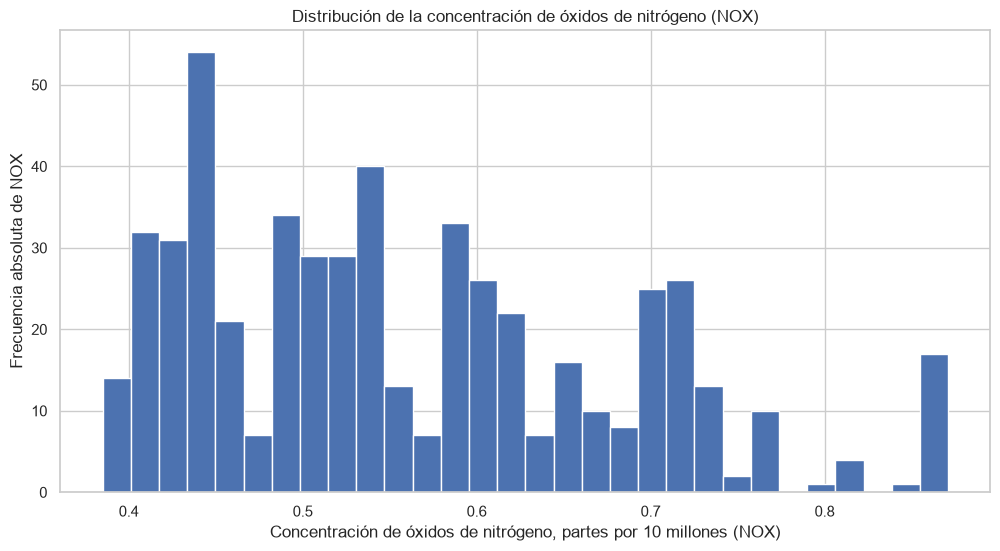

In [13]:
plt.hist(df["NOX"], bins=30)
plt.title("Distribución de la concentración de óxidos de nitrógeno (NOX)")
plt.ylabel("Frecuencia absoluta de NOX")
plt.xlabel("Concentración de óxidos de nitrógeno, partes por 10 millones (NOX)")
plt.show()

La variable **NOX** (concentración de óxidos de nitrógeno, en partes por 10 millones) presenta valores entre 0.385 y 0.871, con una media de aproximadamente 0.560, una mediana de 0.538 y una desviación estándar de 0.119. Su sesgo positivo de aproximadamente 0.69 indica una asimetría moderada con cola hacia la derecha, coherente con que la media sea algo mayor que la mediana. Su curtosis es de aproximadamente -0.23, por lo que puede considerarse una distribución aproximadamente mesocúrtica, con colas similares a las de una normal.

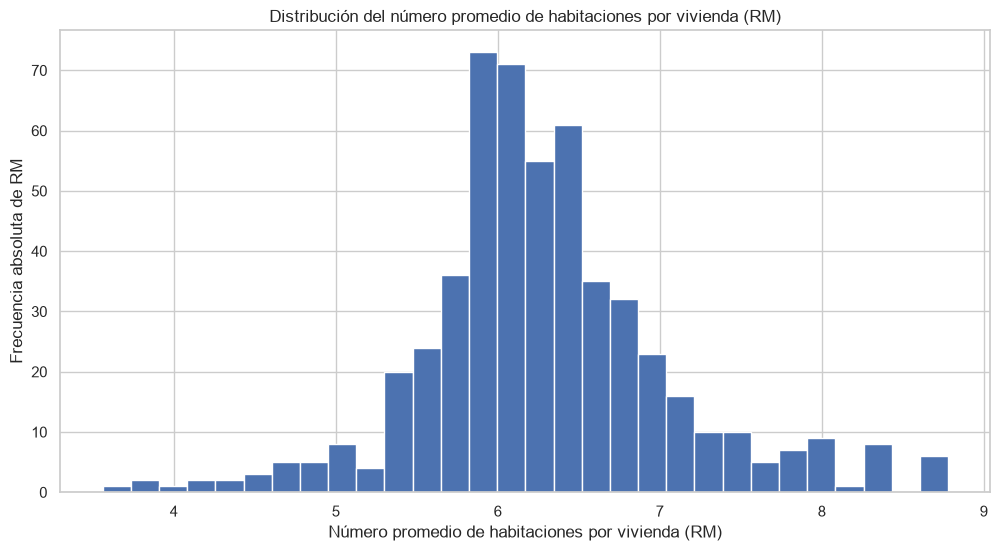

In [14]:
plt.hist(df["RM"], bins=30)
plt.title("Distribución del número promedio de habitaciones por vivienda (RM)")
plt.ylabel("Frecuencia absoluta de RM")
plt.xlabel("Número promedio de habitaciones por vivienda (RM)")
plt.show()

La variable **RM** (número promedio de habitaciones por vivienda) presenta valores entre 3.561 y 8.78, con una media de aproximadamente 6.29, una mediana de 6.21 y una desviación estándar de 0.78, equivalente a cerca del 12% de la media, lo que indica una variación baja respecto de su escala. Su sesgo es de aproximadamente 0.37, por lo que puede considerarse aproximadamente simétrica, lo que coincide con que media y mediana estén muy cercanas. Su curtosis es de aproximadamente 1.56, lo que indica una distribución leptocúrtica: la mayoría de las observaciones se concentra cerca de la media, con algunos valores extremos en ambos lados.

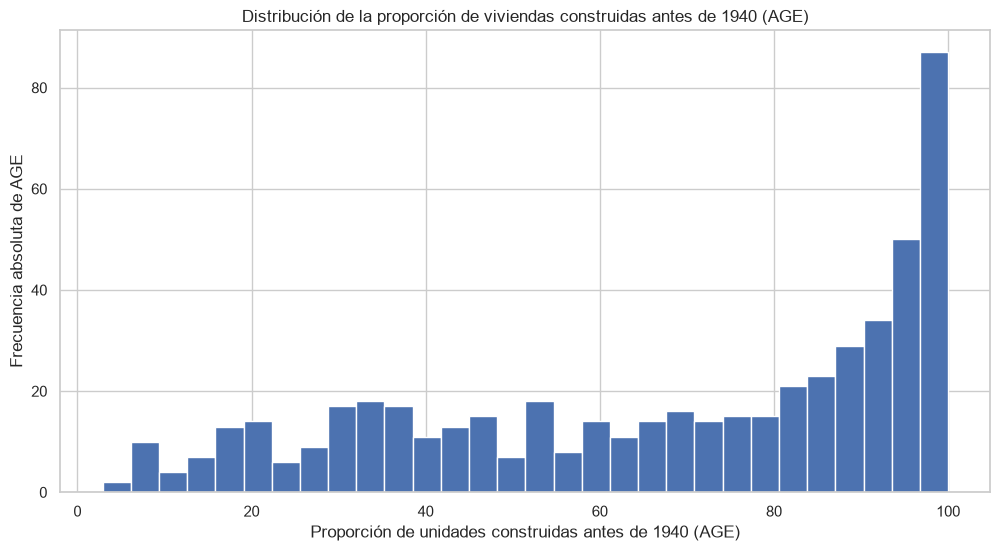

In [15]:
plt.hist(df["AGE"], bins=30)
plt.title("Distribución de la proporción de viviendas construidas antes de 1940 (AGE)")
plt.ylabel("Frecuencia absoluta de AGE")
plt.xlabel("Proporción de unidades construidas antes de 1940 (AGE)")
plt.show()

La variable **AGE** (proporción de unidades ocupadas por sus propietarios construidas antes de 1940) presenta valores entre 2.9 y 100, con una media de aproximadamente 67.63 y una desviación estándar de 28.46, lo que muestra una dispersión alta. La mediana (76.5) es mayor que la media, lo que es coherente con un sesgo negativo de aproximadamente -0.55, es decir, una asimetría moderada con cola hacia la izquierda: la mayoría de las zonas tiene viviendas antiguas y unas pocas tienen viviendas más nuevas. Su curtosis es de aproximadamente -1.04, lo que indica una distribución platicúrtica, achatada y con colas livianas.

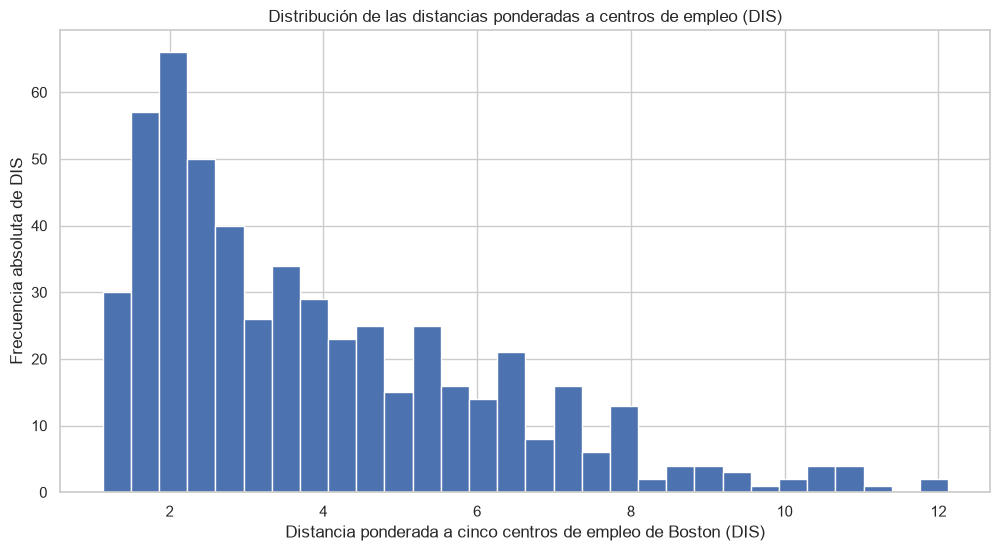

In [16]:
plt.hist(df["DIS"], bins=30)
plt.title("Distribución de las distancias ponderadas a centros de empleo (DIS)")
plt.ylabel("Frecuencia absoluta de DIS")
plt.xlabel("Distancia ponderada a cinco centros de empleo de Boston (DIS)")
plt.show()

La variable **DIS** (distancias ponderadas a cinco centros de empleo de Boston) presenta valores entre 1.1296 y 12.1265, con una media de aproximadamente 3.94, una mediana de 3.34 y una desviación estándar de 2.26, equivalente a cerca del 57% de la media, lo que indica una dispersión considerable. La mediana menor que la media y un sesgo positivo alto de aproximadamente 1.08 indican una distribución asimétrica con cola hacia la derecha: la mayoría de las zonas está relativamente cerca de los centros de empleo y unas pocas están mucho más lejos. Su curtosis es de aproximadamente 0.71, lo que indica una distribución leptocúrtica con colas algo más pesadas que las de una normal.

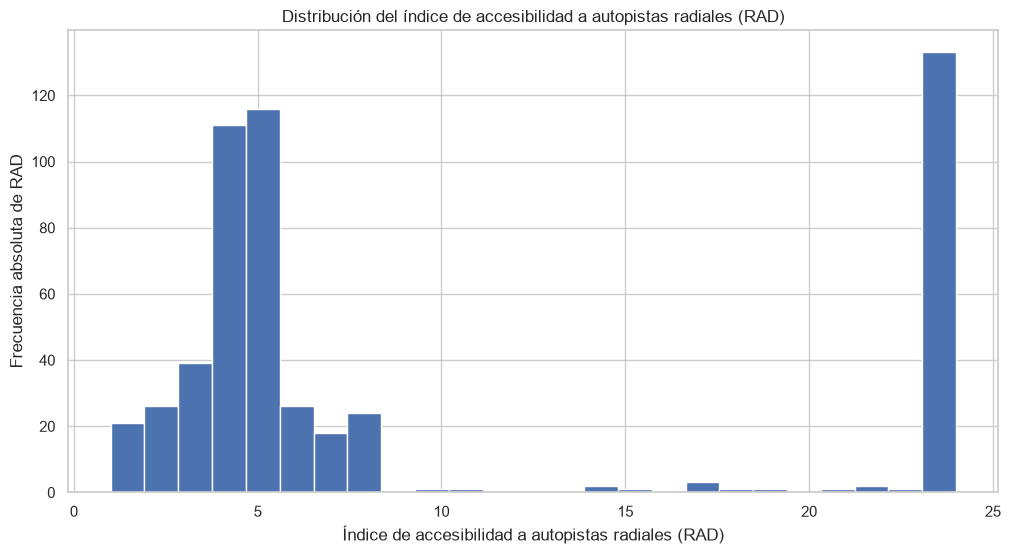

In [17]:
plt.hist(df["RAD"], bins=25)
plt.title("Distribución del índice de accesibilidad a autopistas radiales (RAD)")
plt.ylabel("Frecuencia absoluta de RAD")
plt.xlabel("Índice de accesibilidad a autopistas radiales (RAD)")
plt.show()

In [18]:
# RAD: proporción de observaciones entre 1 y 8, en 24 e intermedias (entre 8 y 24)
rad = df['RAD'].dropna()
print(f"Entre 1 y 8: {(rad <= 8).mean()*100:.1f}% | En 24: {(rad == 24).mean()*100:.1f}% | Intermedias: {((rad > 8) & (rad < 24)).mean()*100:.1f}%")

Entre 1 y 8: 72.2% | En 24: 25.0% | Intermedias: 2.8%


La variable **RAD** (índice de accesibilidad a las autopistas radiales) presenta valores entre 1 y 24, con una media de aproximadamente 9.70 y una desviación estándar de 8.68. La mediana (5) es casi la mitad de la media y existe un salto brusco entre la mediana y el tercer cuartil (23.63), lo que muestra que no es una distribución gradual. 

- Su sesgo es de aproximadamente 0.95, es decir, una asimetría positiva moderada con cola hacia la derecha, y su curtosis es de aproximadamente -0.95, lo que indica una distribución platicúrtica, achatada y con colas livianas. 

- Estos valores se explican por su forma bimodal: cerca del 72% de las observaciones se concentra entre 1 y 8, y el 25% (132 observaciones) toma el valor máximo 24, con prácticamente ninguna observación intermedia. 

- Aunque está codificada como número, RAD es una variable ordinal: el orden importa (mayor valor, mayor accesibilidad), pero la distancia entre sus valores no tiene un significado uniforme.

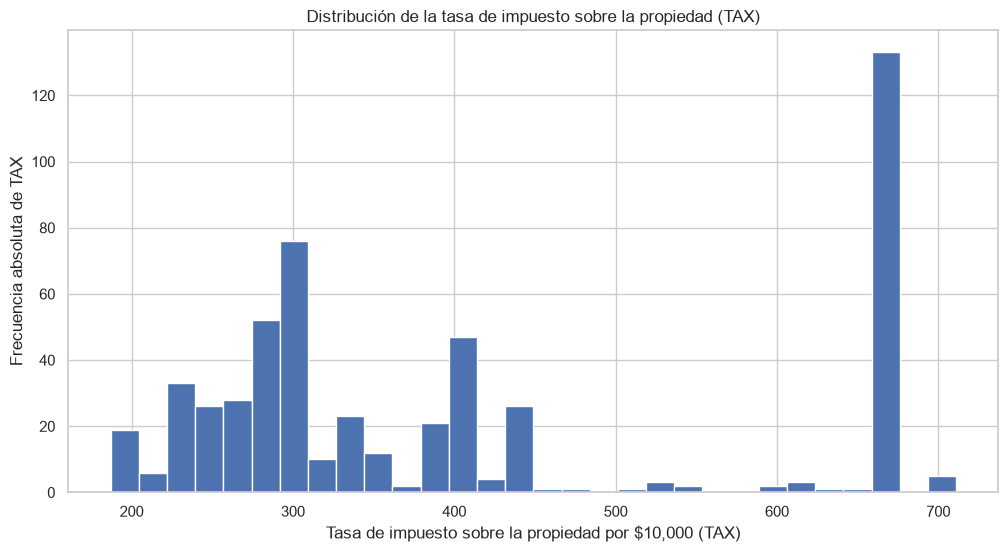

In [19]:
plt.hist(df["TAX"], bins=30)
plt.title("Distribución de la tasa de impuesto sobre la propiedad (TAX)")
plt.ylabel("Frecuencia absoluta de TAX")
plt.xlabel("Tasa de impuesto sobre la propiedad por $10,000 (TAX)")
plt.show()

La variable **TAX** (tasa de impuesto sobre la propiedad a valor completo por $10,000) presenta valores entre 187 y 711, con una media de aproximadamente 409.58, una mediana de 335 y una desviación estándar de 167.69, equivalente a cerca del 41% de la media, lo que indica una dispersión considerable. Su sesgo positivo moderado de aproximadamente 0.63, junto con una mediana menor que la media, indica una distribución asimétrica con cola hacia la derecha. Su curtosis es de aproximadamente -1.17, lo que indica una distribución platicúrtica, achatada y con colas livianas. Esta forma se explica porque cerca del 25% de las observaciones (132) toma exactamente el valor 666, lo que produce una distribución con dos grupos diferenciados, igual que RAD.

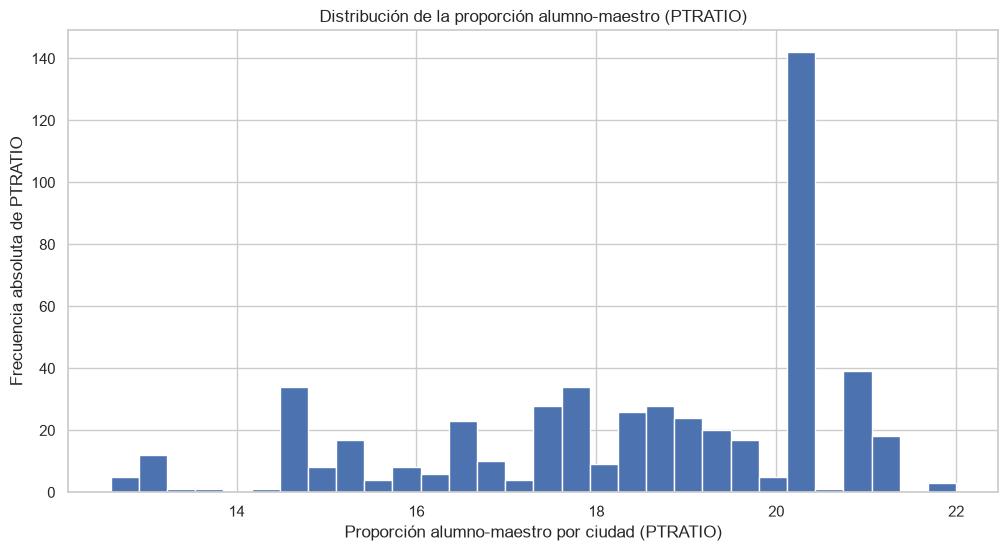

In [20]:
plt.hist(df["PTRATIO"], bins=30)
plt.title("Distribución de la proporción alumno-maestro (PTRATIO)")
plt.ylabel("Frecuencia absoluta de PTRATIO")
plt.xlabel("Proporción alumno-maestro por ciudad (PTRATIO)")
plt.show()

La variable **PTRATIO** (proporción alumno-maestro por ciudad) presenta valores entre 12.6 y 22, con una media de aproximadamente 18.43, una mediana de 19.0 y una desviación estándar de 2.19, equivalente a cerca del 12% de la media, lo que indica una variación relativamente baja. Su sesgo negativo moderado de aproximadamente -0.79, junto con una mediana mayor que la media, indica una distribución asimétrica con cola hacia la izquierda. Su curtosis es de aproximadamente -0.30, por lo que puede considerarse aproximadamente mesocúrtica. Además, cerca del 27% de las observaciones (140) toma exactamente el valor 20.2, lo que genera un pico marcado en esa zona del histograma.

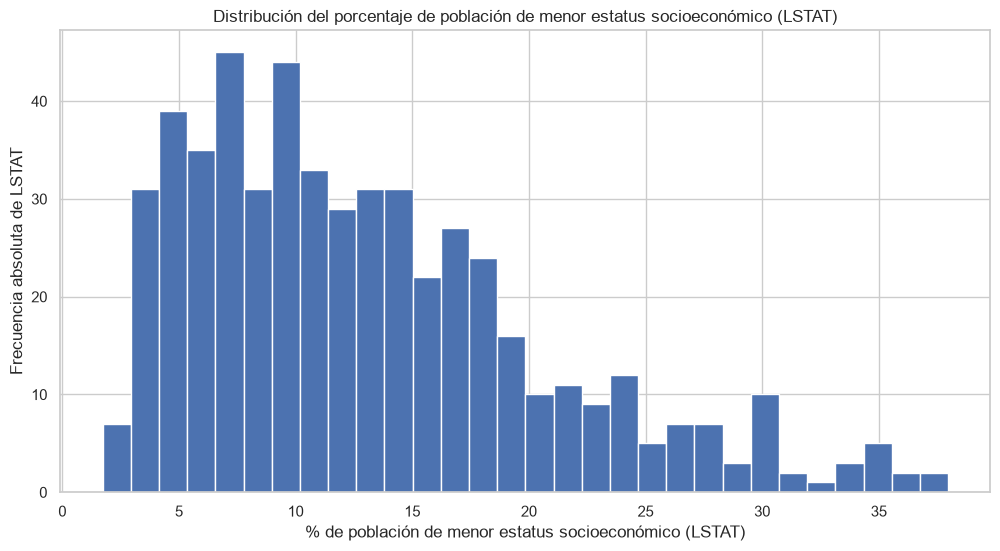

In [21]:
plt.hist(df["LSTAT"], bins=30)
plt.title("Distribución del porcentaje de población de menor estatus socioeconómico (LSTAT)")
plt.ylabel("Frecuencia absoluta de LSTAT")
plt.xlabel("% de población de menor estatus socioeconómico (LSTAT)")
plt.show()

La variable **LSTAT** (% de población de menor estatus socioeconómico) presenta valores entre 1.73 y 37.97, con una media de aproximadamente 13.03, una mediana de 11.47 y una desviación estándar de 7.58, equivalente a cerca del 58% de la media, lo que indica una dispersión considerable. Su sesgo positivo moderado de aproximadamente 0.95, cercano al umbral de 1, junto con una mediana menor que la media, indica una distribución asimétrica con cola hacia la derecha. Su curtosis es de aproximadamente 0.48, por lo que puede considerarse mesocúrtica, con colas similares a las de una normal.

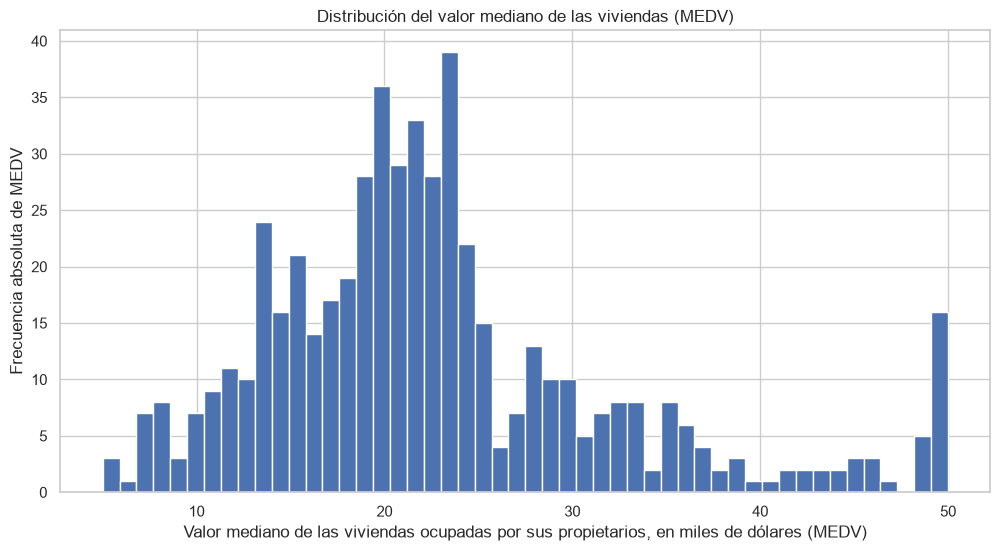

In [22]:
plt.hist(df["MEDV"], bins=50)
plt.title("Distribución del valor mediano de las viviendas (MEDV)")
plt.ylabel("Frecuencia absoluta de MEDV")
plt.xlabel("Valor mediano de las viviendas ocupadas por sus propietarios, en miles de dólares (MEDV)")
plt.show()

La variable **MEDV** (valor mediano de las viviendas ocupadas por sus propietarios, en miles de dólares) presenta valores entre 5 y 50, con una media de aproximadamente 22.75, una mediana de 21.2 y una desviación estándar de 9.49, equivalente a cerca del 42% de la media, lo que indica una dispersión considerable. Su sesgo positivo alto de aproximadamente 1.06 indica una distribución asimétrica con cola hacia la derecha, coherente con que la mediana sea menor que la media. Su curtosis es de aproximadamente 1.17, lo que indica una distribución leptocúrtica con colas pesadas. Además, 16 observaciones (cerca del 3%) toman el valor máximo de 50 lo que sugiere que el valor está truncado en ese límite.

---
## 3.4 Análisis y decisión sobre datos faltantes


In [23]:
# Mostramos el porcentaje de nulos de cada variable respecto al total y la cantidad de faltantes en cada variable
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
reporte_nulos

,Nulos,Porcentaje (%)
PTRATIO,28,5.04
RAD,28,5.04
NOX,24,4.32
AGE,24,4.32
CHAS,23,4.14
CRIM,23,4.14
LSTAT,22,3.96
B,22,3.96
ZN,22,3.96
RM,21,3.78


- Cada columna tiene entre 2.70% y 5.04% de nulos.

In [24]:
# Distribución de filas según cantidad y porcentaje de columnas faltantes
nulos_por_fila = df.isnull().sum(axis=1)
dist = nulos_por_fila.value_counts().sort_index().to_frame('Filas')
dist['% columnas faltantes'] = (dist.index / df.shape[1] * 100).round(1)
dist

,Filas,% columnas faltantes
0,506,0.0
1,5,7.1
2,3,14.3
3,11,21.4
4,3,28.6
5,3,35.7
6,2,42.9
7,5,50.0
8,4,57.1
9,4,64.3


La tabla muestra cuántas filas tienen cada cantidad de columnas faltantes, junto con el porcentaje que eso representa sobre las 14 columnas del dataset. La mayoría de las filas (506 de 556, cerca del 91%) están completas. Las 50 filas restantes tienen al menos un dato faltante y se dividen en tres grupos: 
- 27 filas con entre 1 y 6 columnas faltantes (menos del 50%), que mantienen información suficiente para imputar. 
- 5 filas con 7 columnas faltantes, justo en el límite del 50% 
- 18 filas (3.2% del total) con 8 o más columnas faltantes, incluida una con las 14 columnas vacías. En estas últimas casi no queda información real, por lo que un método como KNN no podría encontrar vecinos representativos.

Se observa que la **variable objetivo MEDV tiene 21 valores faltantes** (3.78% del total). Se decide eliminar esas filas en lugar de imputarlas: imputar el target implicaría introducir datos artificiales justamente en la variable que el modelo debe aprender a predecir, lo que podría distorsionar el entrenamiento, y además una fila sin valor real de MEDV no permite evaluar la predicción del modelo.

In [25]:
df = df.dropna(subset=["MEDV"])

In [26]:
# Recalculamos cantidad y porcentaje de nulos por variable luego de eliminar los faltantes en la variable MEDV
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
reporte_nulos

,Nulos,Porcentaje (%)
RAD,12,2.24
ZN,11,2.06
CRIM,11,2.06
AGE,11,2.06
CHAS,9,1.68
B,9,1.68
NOX,9,1.68
PTRATIO,9,1.68
TAX,9,1.68
LSTAT,9,1.68


In [27]:
# Después de eliminar las filas con MEDV nulo: nueva distribución de columnas faltantes por fila
nulos_por_fila = df.isnull().sum(axis=1)
dist = nulos_por_fila.value_counts().sort_index().to_frame('Filas')
dist['% columnas faltantes'] = (dist.index / df.shape[1] * 100).round(1)
dist

,Filas,% columnas faltantes
0,506,0.0
1,5,7.1
2,3,14.3
3,9,21.4
4,2,28.6
5,2,35.7
6,1,42.9
7,4,50.0
8,2,57.1
9,1,64.3


Tras eliminar las 21 filas con MEDV faltante, el dataset queda con 535 filas y el target ya no tiene nulos. Los faltantes del resto de las variables también bajan: ahora cada una tiene entre 0.75% y 2.24% (antes entre 2.70% y 5.04%). Además, 506 filas (94.6%) están completas y solo 3 (0.6%) superan el 50% de columnas faltantes, con 8 o 9 de las 14 columnas vacías. Esto indica que buena parte de los datos faltantes estaba concentrada en las mismas filas que tenían MEDV vacío, y que la regla del 50% afecta a muy pocas filas adicionales.

In [28]:
# Eliminar filas con mas del 50% de columnas faltantes
pct_nulos_fila = df.isnull().sum(axis=1) / df.shape[1] * 100

print('Filas con mas del 50% de columnas faltantes:', (pct_nulos_fila > 50).sum())

df = df[pct_nulos_fila <= 50]

Filas con mas del 50% de columnas faltantes: 3


Elegimos un 50% para que garantice que la fila conserve más información real que faltante.

En total se eliminaron 24 filas de 556 (4.32%), por debajo del límite del 5% establecido para no generar un desvío estadístico en el dataset.

In [29]:
# Chequeo de filas duplicadas
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados} de {len(df)} ({n_duplicados/len(df)*100:.2f}%)')

Filas duplicadas: 0 de 532 (0.00%)


No se encontraron datos duplicados en el dataset, por lo que no fue necesaria ninguna decisión de eliminación en este aspecto.

### Análisis del mecanismo de los datos faltantes (MCAR / MAR / MNAR)

- MCAR -> la falta de dato aparece al azar y no depende de ninguna otra varaible.
- MAR -> la falta del dato depende de otras varaibles observadas, eliminar aca sesga, imputar con KNN
- MNAR -> la falta depende del propio valor faltante

In [30]:
# Comparación de medianas entre filas con y sin datos faltantes
tiene_nulo = df.isnull().any(axis=1)
comparacion = pd.DataFrame({
    'mediana_con_nulo': df[tiene_nulo].median(),
    'mediana_sin_nulo': df[~tiene_nulo].median()
}).round(2)
print(f'Filas con algún nulo: {tiene_nulo.sum()} de {len(df)}')
comparacion

Filas con algún nulo: 26 de 532


,mediana_con_nulo,mediana_sin_nulo
CRIM,42.24,0.26
ZN,51.70,0.00
INDUS,12.83,9.69
CHAS,1.00,0.00
NOX,0.66,0.54
RM,5.66,6.21
AGE,35.54,77.50
DIS,5.24,3.21
RAD,14.20,5.00
TAX,481.93,330.00


Se comparan las filas con al menos un dato faltante (26 filas) contra las completas (506). Las filas con faltantes presentan medianas muy distintas en varias variables: mayor CRIM (42.24 contra 0.26), mayor ZN (51.70 contra 0), mayor LSTAT (24.42 contra 11.36) y mayor DIS (5.24 contra 3.21), y menor B (208.32 contra 391.44) y menor AGE (35.54 contra 77.50). Esto sugiere que los faltantes se concentran en un perfil particular de zona (mayor criminalidad, más terrenos zonificados para lotes grandes, más lejos de los centros de empleo y con mayor proporción de población de menor estatus), mientras que las filas completas corresponden al perfil opuesto. Como la presencia de faltantes se asocia con los valores de otras variables observadas, se descarta que la falta de datos sea completamente aleatoria (MCAR). Este análisis es exploratorio: se basa en solo 26 filas con faltantes.

**Conclusión:** con este análisis no es posible determinar con certeza si el mecanismo es MAR o MNAR: la asociación con variables observadas es consistente con MAR, pero no se puede comprobar si la falta también depende del propio valor faltante. Se adopta MAR como supuesto de trabajo. Bajo ese supuesto, eliminar las filas incompletas sesgaría el dataset, porque se descartaría sistemáticamente ese tipo de zonas, por lo que se decide imputar.

---
## 3.5 Visualización de datos

### Distribución de las variables

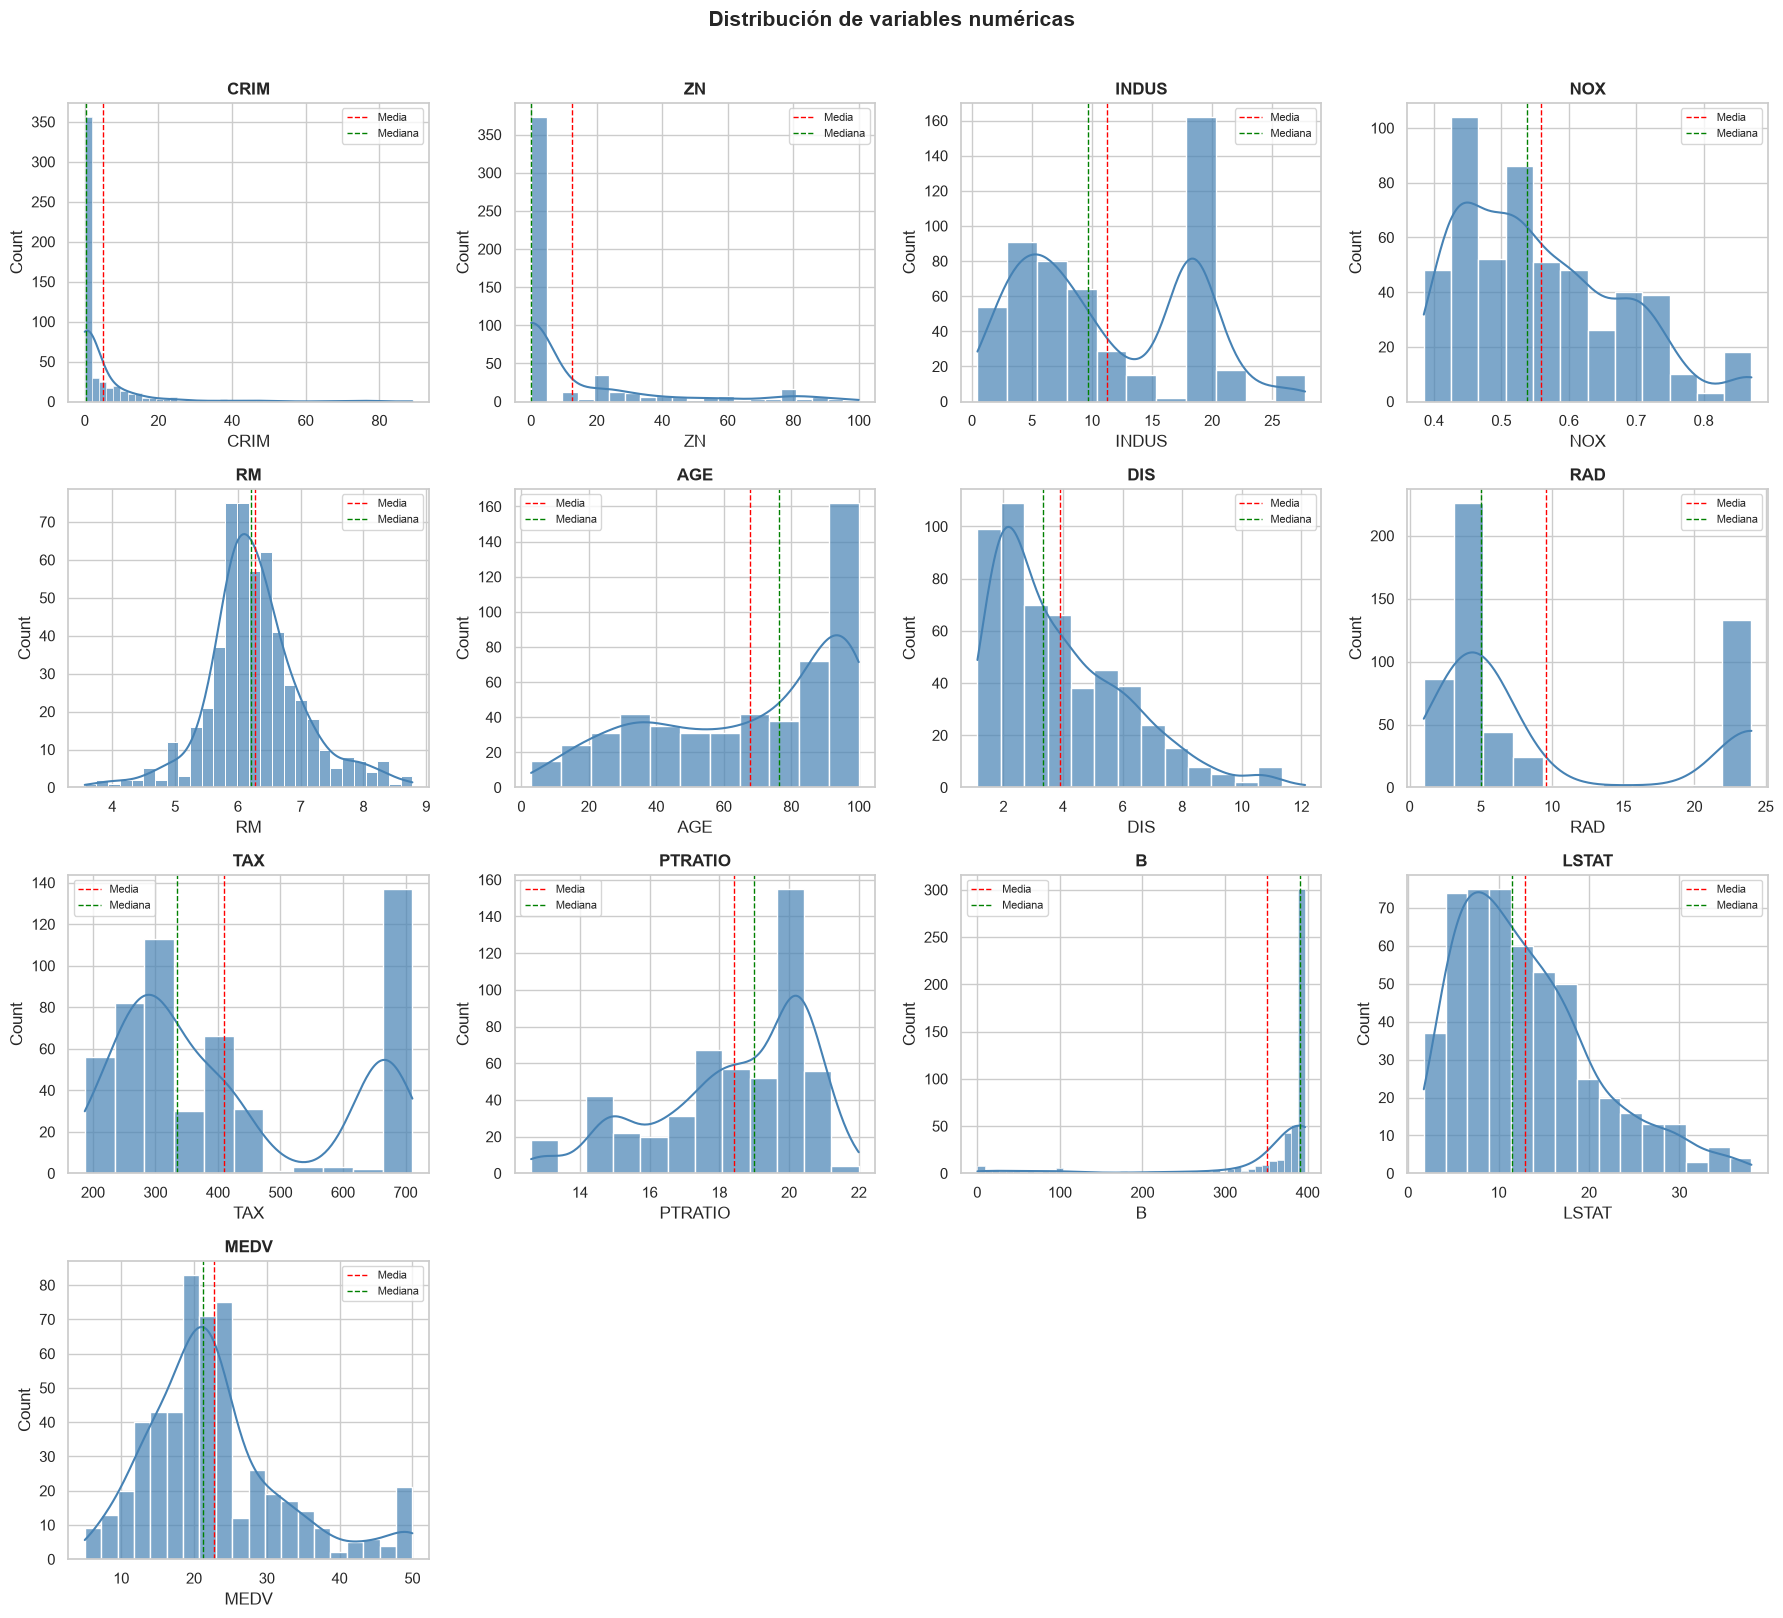

In [31]:
# Histogramas de todas las variables numéricas
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas + ['MEDV']):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Media')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1, label='Mediana')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(len(cols_numericas) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los histogramas confirman visualmente lo observado en las medidas de sesgo y curtosis:

- **Sesgo positivo alto (cola derecha larga):** CRIM, ZN y DIS. La mayoría de las observaciones se concentra en valores bajos, con una cola de casos extremos poco frecuentes (sesgo de CRIM: 3.75, ZN: 1.96, DIS: 1.08). LSTAT (0.95) presenta una asimetría positiva moderada.

- **Sesgo negativo (cola izquierda):** B y AGE. En B, la mayoría de los valores se acumula cerca del máximo, con pocos casos de valores bajos (sesgo: -2.40). En AGE la asimetría es moderada (-0.55).

- **Dos concentraciones diferenciadas (posible distribución bimodal):** RAD y TAX. En RAD hay un grupo grande de valores bajos (entre 1 y 8) y otro concentrado en el máximo, 24, con prácticamente ninguna observación intermedia. En TAX ocurre algo similar: un grupo principal de valores bajos y medios, y una concentración adicional en 666 (cerca del 25% de las observaciones), próxima al máximo de 711.

- **Distribución aproximadamente simétrica:** RM tiene forma de campana, con media y mediana cercanas (6.29 y 6.21) y un sesgo de 0.37.

- **MEDV (target):** presenta sesgo positivo alto (1.06), con una concentración de valores entre 20 y 25 y una acumulación de observaciones exactamente en 50, lo que es un posible indicio de que el valor está truncado en ese límite.

### Detección de valores atípicos

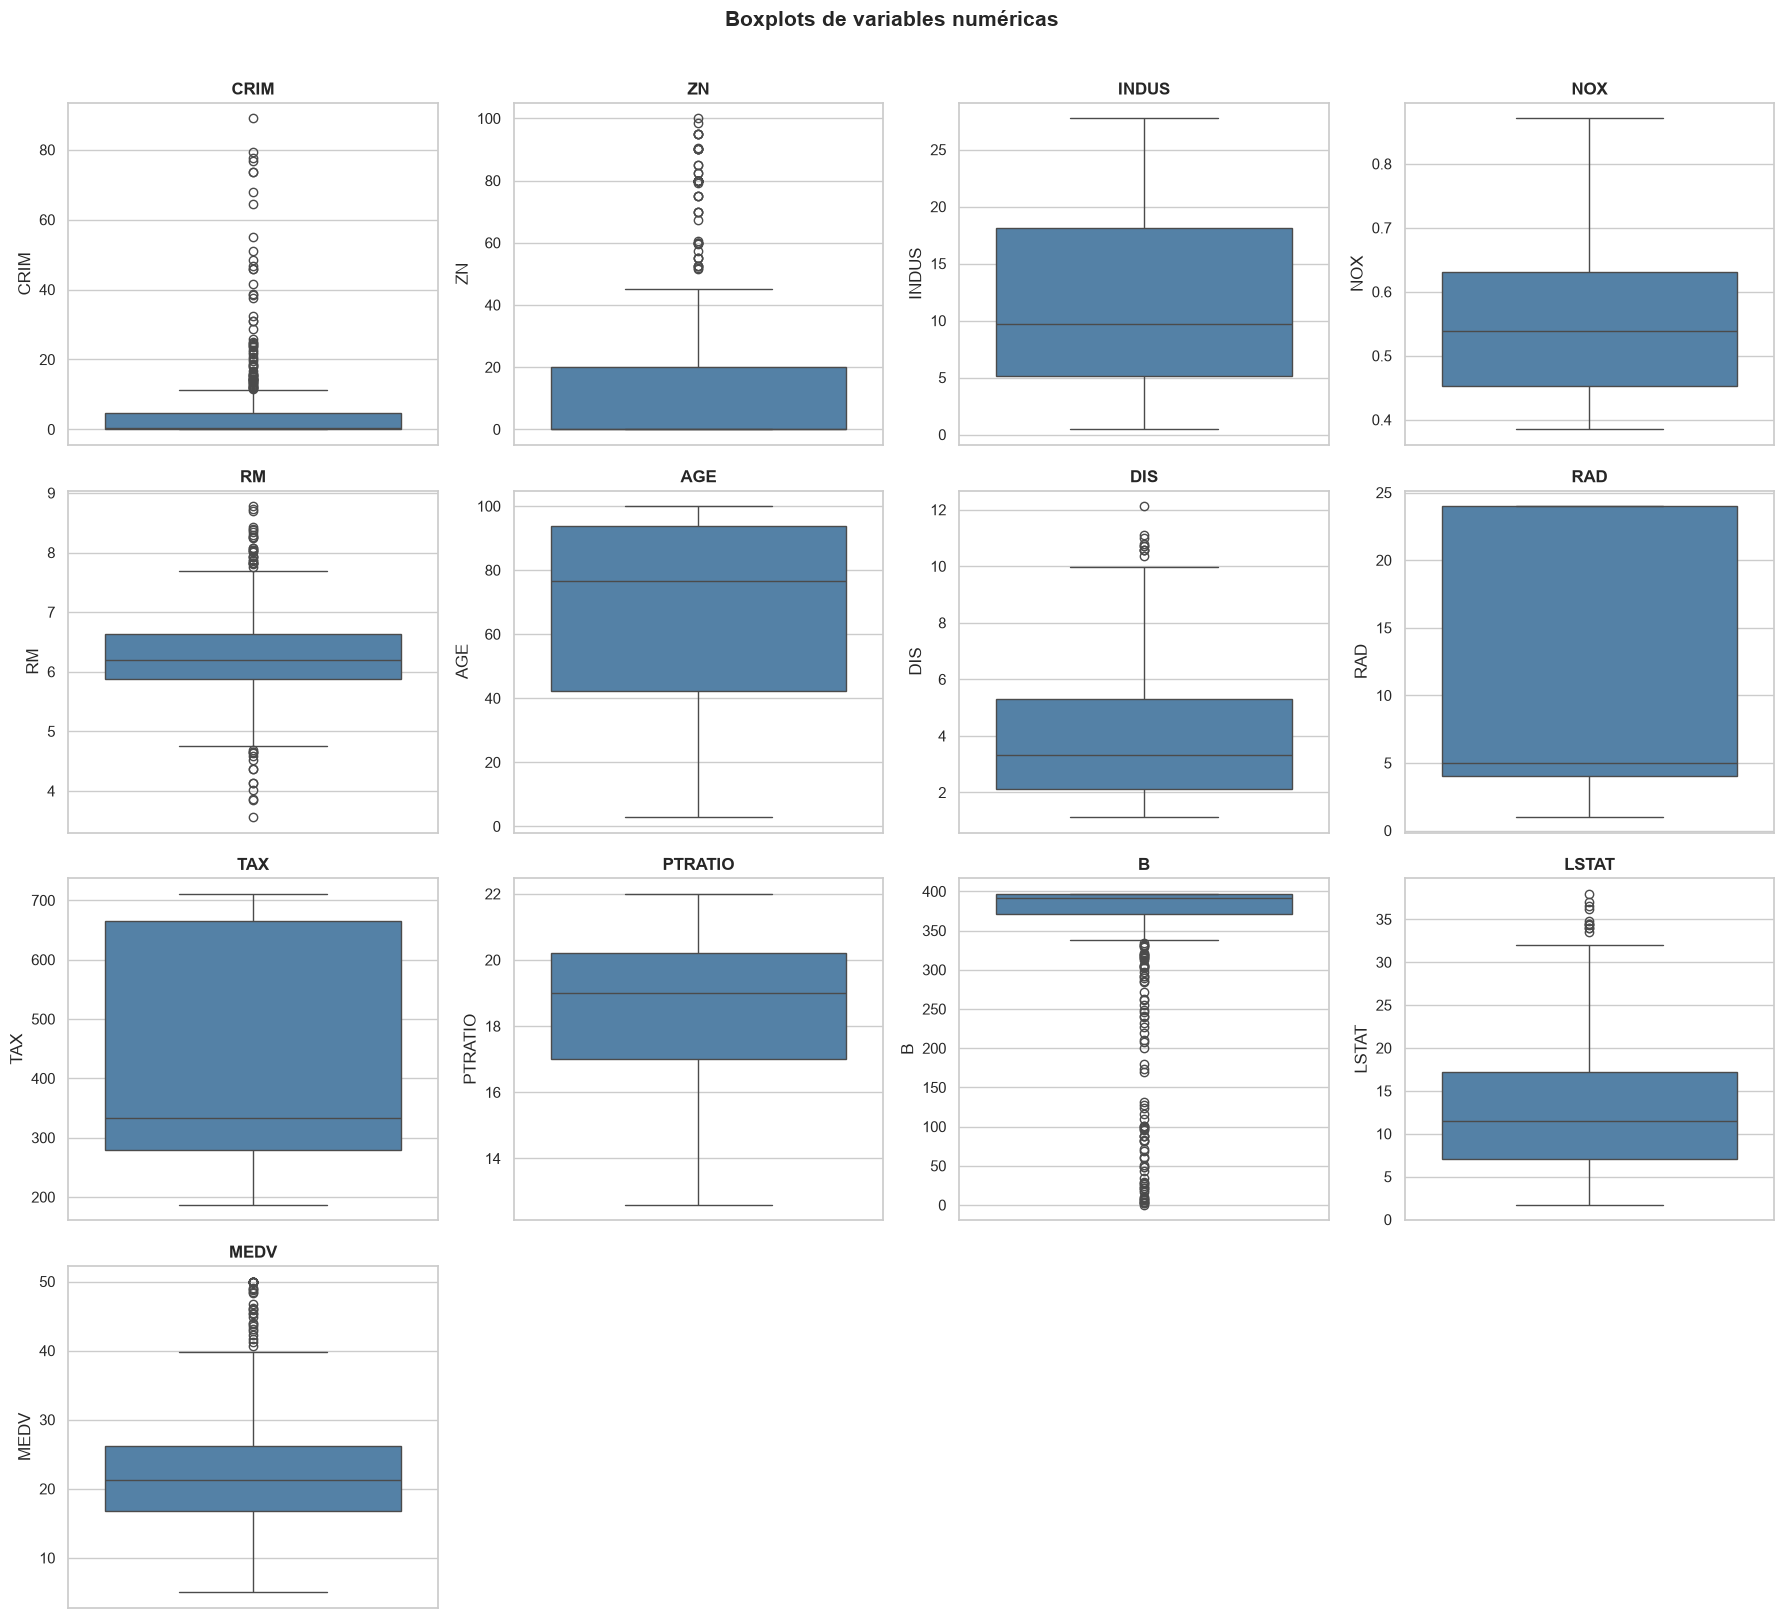

In [32]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas + ['MEDV']):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')

for j in range(len(cols_numericas) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los boxplots muestran valores por fuera de los bigotes (1.5 × IQR) en varias variables. Estos outliers se cuantifican y se define su tratamiento en la sección 3.8.

### Visualización de la relación de cada varable contra el target MEDV

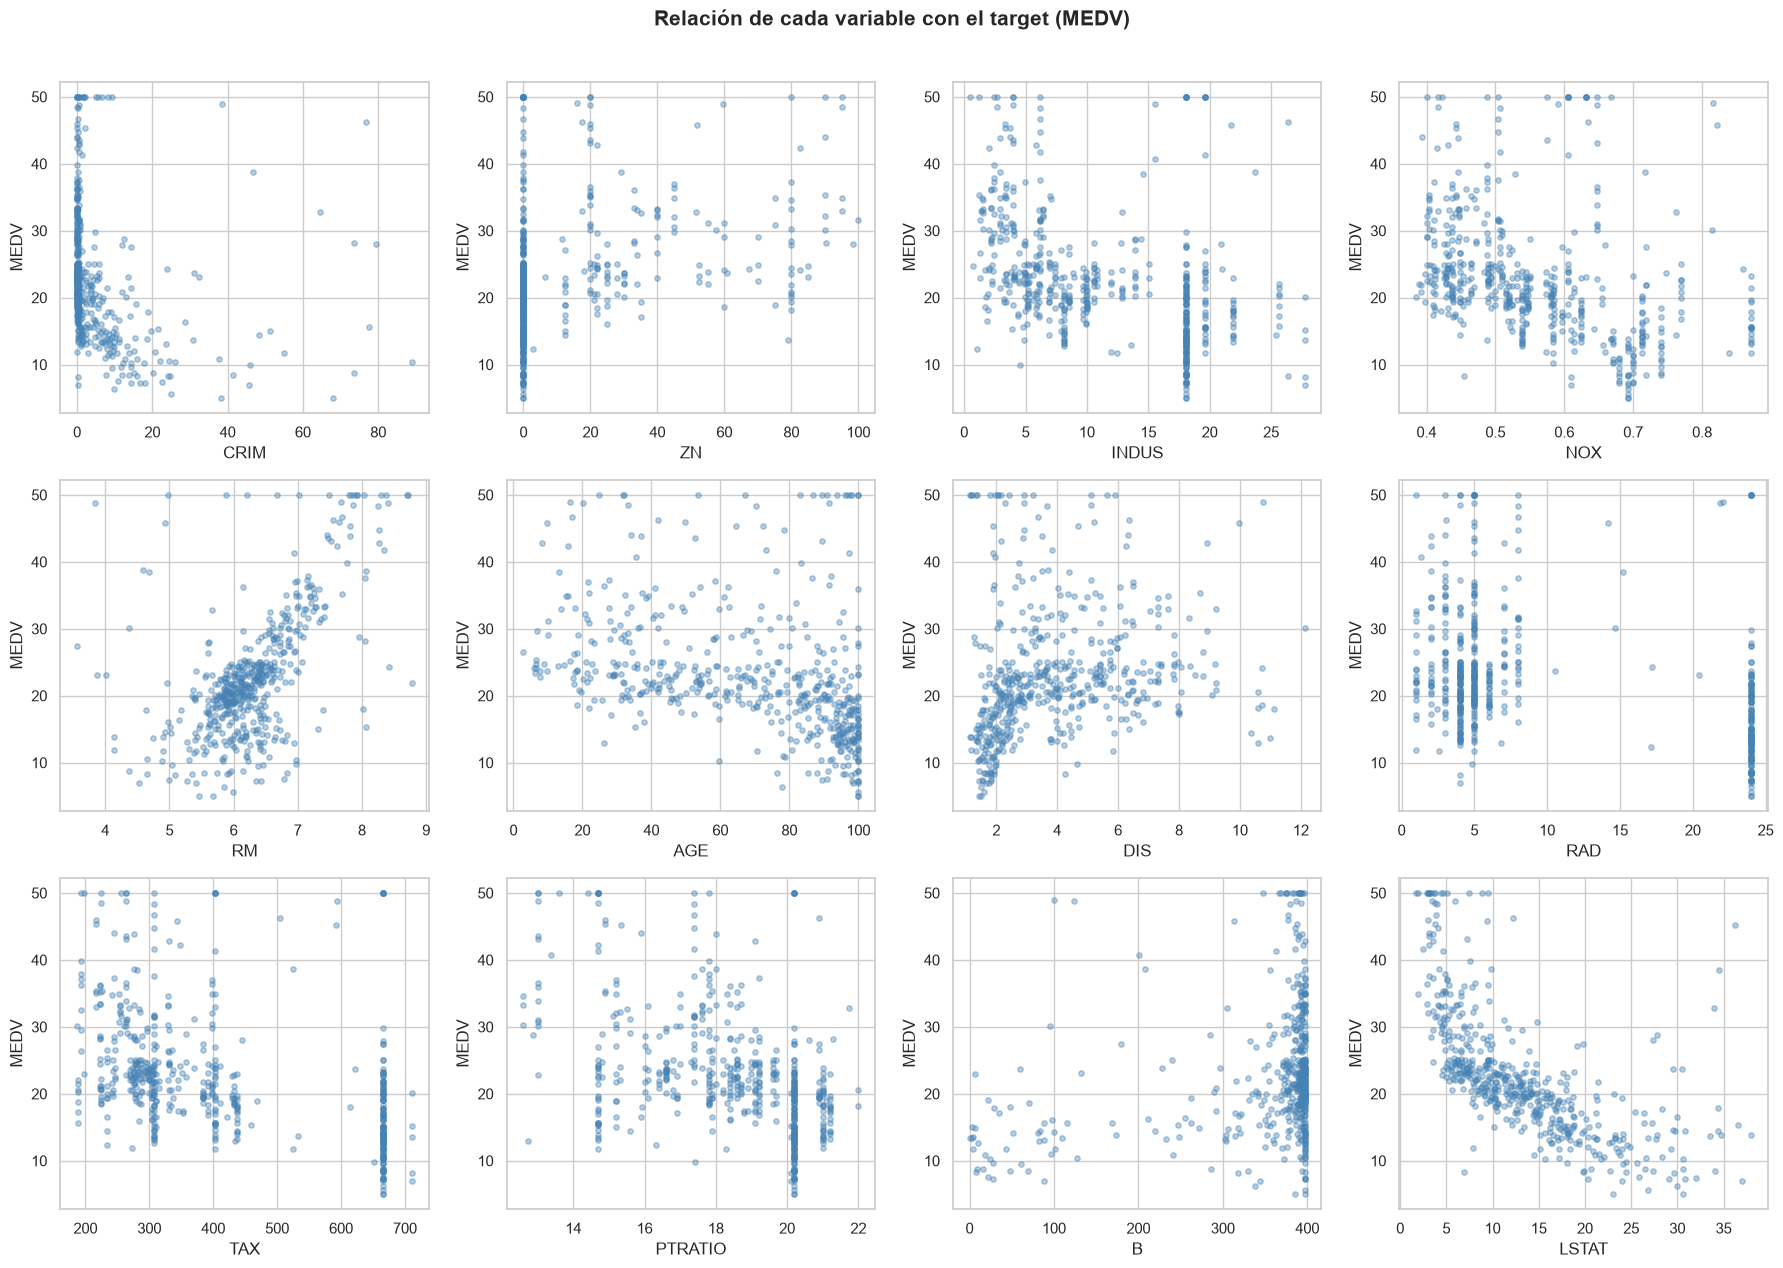

In [33]:
# Scatterplots de cada variable contra el target MEDV
# da una idea de qué variables tienen relación lineal fuerte con el precio (MEDV)
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    ax.scatter(df[col], df['MEDV'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('MEDV')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relación de cada variable con el target (MEDV)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Patrones:

- **RM** muestra una relación positiva: a mayor número de habitaciones 
  promedio, mayor precio, tendencia ascendente bastante definida.
- **LSTAT** muestra una relación negativa marcada, pero con una forma curva: el precio cae fuerte para valores bajos de LSTAT y despues la caída se aplana. 
Esto sugiere que una transformación no lineal podría representar mejor esta relación.

- Variables como CRIM, DIS, CHAS y B se ven como nubes de puntos más dispersas, sin una tendencia lineal clara.

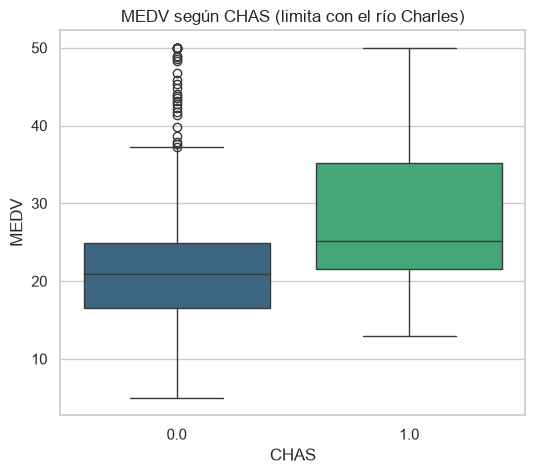

In [34]:
# MEDV según la variable dummy CHAS (para determinar si limitar con el río impacta en el precio)
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x=col_categorica, y='MEDV', palette='viridis')
plt.title('MEDV según CHAS (limita con el río Charles)')
plt.show()

El boxplot de MEDV según CHAS muestra que las zonas que limitan con el rio (CHAS=1) 
tienden a tener precios más altos (mediana 25.1) que las que no limitan (mediana 20.9). Sin 
embargo, el grupo CHAS=1 representa una fracción pequeña del dataset (45 filas)

---
## 3.6 Codificación de variables categóricas

**CHAS** es la única variable categórica del dataset y ya viene como dummy (0/1),
por lo tanto no requiere un encoding adicional.

Sin embargo, presenta valores faltantes, por lo que será necesario definir una estrategia de imputación antes de utilizarla en los modelos.

---
## 3.7 Matriz de correlación

In [35]:
corr = df.corr(method='pearson')
corr.round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,0.01,0.34,0.15,0.37,-0.17,0.22,-0.18,0.53,0.48,0.25,-0.40,0.43,-0.23
ZN,0.01,1.00,-0.47,0.02,-0.45,0.26,-0.57,0.65,-0.29,-0.29,-0.35,0.12,-0.34,0.36
INDUS,0.34,-0.47,1.00,0.10,0.73,-0.36,0.60,-0.63,0.58,0.70,0.37,-0.32,0.54,-0.42
CHAS,0.15,0.02,0.10,1.00,0.12,-0.01,0.03,-0.04,0.01,-0.04,-0.11,-0.05,-0.00,0.21
NOX,0.37,-0.45,0.73,0.12,1.00,-0.27,0.67,-0.66,0.60,0.64,0.18,-0.39,0.56,-0.36
RM,-0.17,0.26,-0.36,-0.01,-0.27,1.00,-0.21,0.19,-0.22,-0.26,-0.33,0.14,-0.53,0.59
AGE,0.22,-0.57,0.60,0.03,0.67,-0.21,1.00,-0.73,0.43,0.49,0.25,-0.21,0.55,-0.39
DIS,-0.18,0.65,-0.63,-0.04,-0.66,0.19,-0.73,1.00,-0.46,-0.49,-0.23,0.19,-0.42,0.23
RAD,0.53,-0.29,0.58,0.01,0.60,-0.22,0.43,-0.46,1.00,0.88,0.46,-0.43,0.47,-0.35
TAX,0.48,-0.29,0.70,-0.04,0.64,-0.26,0.49,-0.49,0.88,1.00,0.44,-0.42,0.52,-0.44


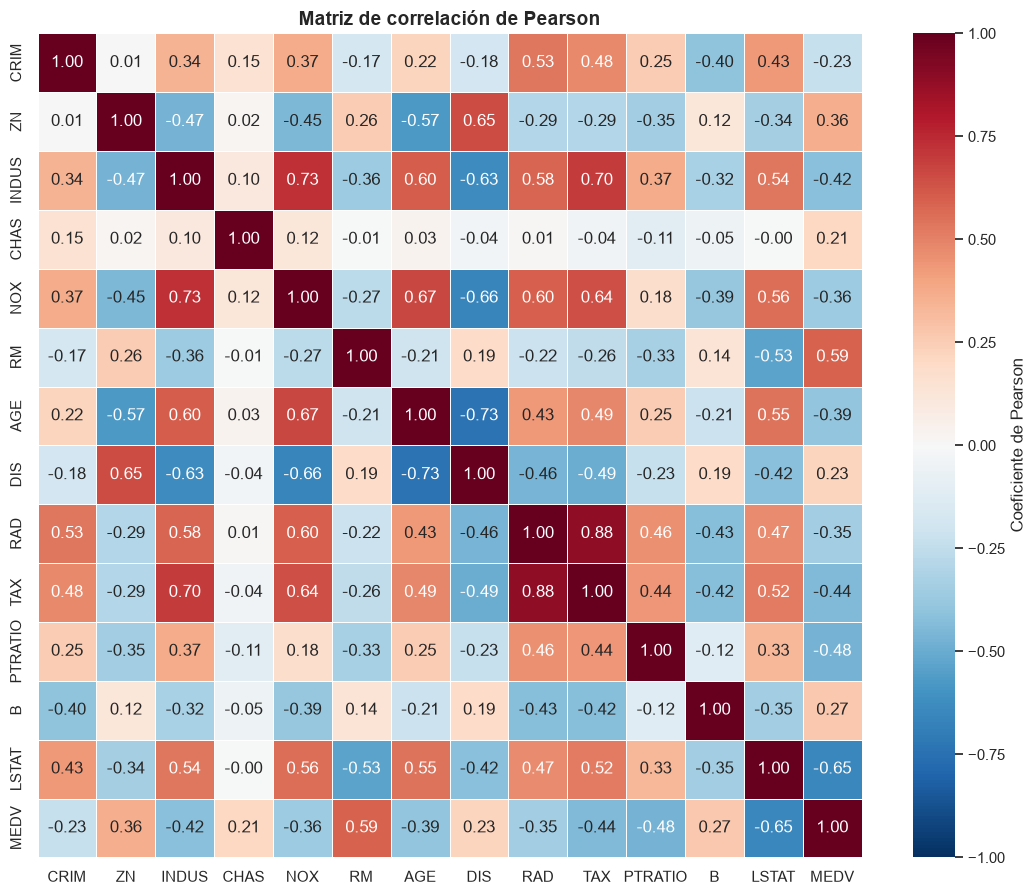

In [36]:


plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de Pearson'})
plt.title('Matriz de correlación de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlación con el target (MEDV):**

Las variables con mayor correlación lineal con MEDV son LSTAT (r = -0.65) y RM (r = 0.59), consistente con lo observado en los scatterplots de la sección anterior: a mayor porcentaje de población de menor estatus (LSTAT), menor valor de las viviendas, y a mayor número promedio de habitaciones (RM), mayor valor. Con correlación moderada le siguen PTRATIO (r = -0.48), TAX (r = -0.44), INDUS (r = -0.42), AGE (r = -0.39), NOX (r = -0.36), ZN (r = 0.36) y RAD (r = -0.35). Las variables B (r = 0.27), CRIM (r = -0.23), DIS (r = 0.23) y CHAS (r = 0.21) muestran una correlación lineal más débil con el precio, aunque esto no implica que no puedan aportar información predictiva, de forma no lineal.

**Colinealidad entre variables predictoras:**

Tomando como referencia |r| >= 0.7, se identifican tres pares con relación lineal fuerte entre sí:

- **RAD y TAX (r = 0.88):** es la correlación más alta del dataset. Coincide con el patrón bimodal detectado antes en ambas variables.
- **INDUS y NOX (r = 0.73):** las zonas con mayor proporción de negocios no minoristas tienden a tener mayor concentración de óxidos de nitrógeno.
- **AGE y DIS (r = -0.73):** las zonas con viviendas más antiguas tienden a estar más cerca de los centros de empleo.

Estas relaciones indican una posible multicolinealidad entre predictores. Esto es relevante en regresión lineal, ya que una multicolinealidad elevada puede dificultar la interpretación de los coeficientes y hacer que sus estimaciones sean menos estables.

---
## 3.8 Outliers 

### Detección método IQR

In [37]:
cols_iqr = [c for c in df.columns if c != 'CHAS']

Q1 = df[cols_iqr].quantile(0.25)
Q3 = df[cols_iqr].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ((df[cols_iqr] < limite_inferior) | (df[cols_iqr] > limite_superior)).sum()
porcentaje_outliers = (outliers / len(df) * 100).round(2)

print('Outliers por variable:')
print(outliers)
print()
print('Porcentaje de outliers por variable:')
print(porcentaje_outliers)

Outliers por variable:
CRIM       64
ZN         54
INDUS       0
NOX         0
RM         41
AGE         0
DIS        10
RAD         0
TAX         0
PTRATIO     0
B          86
LSTAT      11
MEDV       37
dtype: int64

Porcentaje de outliers por variable:
CRIM       12.03
ZN         10.15
INDUS       0.00
NOX         0.00
RM          7.71
AGE         0.00
DIS         1.88
RAD         0.00
TAX         0.00
PTRATIO     0.00
B          16.17
LSTAT       2.07
MEDV        6.95
dtype: float64


Se excluye CHAS de este análisis porque al ser una variable binaria el método IQR no es aplicable

In [38]:
# Filas con al menos un outlier en alguna variable
filas_con_outlier = ((df[cols_iqr] < limite_inferior) | (df[cols_iqr] > limite_superior)).any(axis=1)
print(f'Filas con al menos un outlier: {filas_con_outlier.sum()} de {len(df)} ({filas_con_outlier.mean()*100:.1f}%)')

Filas con al menos un outlier: 196 de 532 (36.8%)


Se optó por no eliminar los valores atípicos detectados con el criterio IQR. Las variables INDUS, NOX, AGE, RAD, TAX y PTRATIO no presentan outliers, y CHAS se excluye por ser binaria. Para el resto, los motivos son:

- **No hay indicios de errores de carga.** Los valores extremos de CRIM (12.03% de outliers), B (16.17%), ZN (10.15%), RM (7.71%), LSTAT (2.07%) y DIS (1.88%) forman parte de la distribución real de los datos y corresponden a zonas con perfiles urbanos distintos, poco frecuentes pero posibles.

- **Eliminarlos sesgaría el dataset.** 196 filas (36.8%) tienen al menos un outlier, por lo que se descartaría más de un tercio de los datos. Además, los valores altos de CRIM y los valores bajos de B corresponden al mismo perfil de zona que se observó en las filas con datos faltantes (mayor criminalidad y menor B). Eliminarlos introduciría el mismo sesgo que se buscó evitar al imputar en lugar de eliminar los nulos.

- **MEDV es un caso particular.** De sus 37 outliers, 16 son observaciones acumuladas exactamente en el valor máximo de 50, lo que sugiere un límite superior de registro del dataset y no necesariamente el precio real de esas zonas. Aun así se conservan, porque eliminarlas implicaría perder información de viviendas de alto valor.

---
## 3.9 Estrategia de imputación de valores faltantes

Tras eliminar las filas con el target vacío y las que tienen más del 50% de sus columnas faltantes, quedan 90 datos faltantes en las variables predictoras: 83 en variables numéricas y 7 en CHAS. Como se concluyó en la sección de datos faltantes, se asume un mecanismo MAR y eliminar esas filas sesgaría el dataset, por lo que se decide imputarlas. La imputación se realiza **después** de dividir en train y test, y todos los pasos que aprenden parámetros de los datos se ajustan únicamente con train, para evitar data leakage.

### Variables numéricas: KNN (k = 5)

- **KNN** completa cada valor faltante con el promedio de las 5 filas más parecidas según el resto de las variables observadas. Esto es coherente con el supuesto MAR, ya que aprovecha justamente la información de las otras variables. En cambio, imputar con la media o la mediana impondría un único valor global e ignoraría el perfil de la zona: en 3.4 se vio que los faltantes se concentran en zonas con características particulares (mayor criminalidad, menor B, etc.).
- **Se usa k = 5**, el valor por defecto de scikit-learn, sin ajustarlo.
- **No se incluye MEDV en la imputación.** El target no se usa para completar las variables predictoras, porque en test el valor de MEDV no está disponible al predecir y usarlo generaría una fuga de información.
- **Estandarización previa (RobustScaler):** KNN se basa en distancias, por lo que las variables deben estar en la misma escala, de lo contrario las de mayor rango (como TAX o B) determinarían casi por completo qué filas se consideran vecinas. Se usa RobustScaler porque variables como CRIM y B presentan outliers marcados, y StandardScaler es sensible a estos valores extremos al calcular la media y el desvío. Es un escalado temporal, solo para calcular distancias: luego se revierte con `inverse_transform`.


### CHAS (categórica): moda

- KNN promediaría los valores de los vecinos y generaría valores intermedios (por ejemplo, 0.4), que no son válidos en una variable binaria.
- Se optó por imputar CHAS con la moda. CHAS es una variable muy desbalanceada (cerca del 91% de sus valores conocidos son 0), por lo que la clase mayoritaria ya es, en sí misma, una predicción razonable. Además, solo hay 7 valores faltantes (1.3% de la variable), un volumen demasiado chico como para justificar un modelo más complejo. Por eso se imputa con la moda calculada solo con train, que es más simple.


### Orden

1. División en train y test
2. Imputación de las numéricas con KNN (RobustScaler temporal)
3. Imputación de CHAS con la moda
4. Transformación logarítmica de CRIM y DIS
5. Estandarización final de las variables numéricas (StandardScaler)



## 3.9.1 División train / test

**Nota:** para evitar data leakage, la imputación con KNN se aplica recién **después** del split, 
ajustando el imputador únicamente con los datos de entrenamiento. Así el conjunto de 
test nunca influye en cómo se completan los valores faltantes de train, ni viceversa.

In [39]:
# Split ANTES de imputar y de estandarizar (evita data leakage en ambos pasos).
# nulos: se imputan recien despues de dividir el dataset
# Se estratifica por CHAS (los NaN forman un tercer estrato) para que train y test
# tengan la misma proporcion de tramos que limitan con el rio.

X = df[cols_numericas + [col_categorica]]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
    stratify=X[col_categorica].fillna(-1))

print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'Nulos en X_train: {X_train.isnull().sum().sum()} | Nulos en X_test: {X_test.isnull().sum().sum()}')
print(f'Nulos en y_train: {y_train.isnull().sum()} | Nulos en y_test: {y_test.isnull().sum()}')
print('Distribución de CHAS (%):')
print(pd.DataFrame({
    'train': X_train[col_categorica].value_counts(normalize=True, dropna=False),
    'test': X_test[col_categorica].value_counts(normalize=True, dropna=False)
}).mul(100).round(2))

Train: 425 filas | Test: 107 filas
Nulos en X_train: 72 | Nulos en X_test: 18
Nulos en y_train: 0 | Nulos en y_test: 0
Distribución de CHAS (%):
      train   test
CHAS              
0.0   90.12  90.65
1.0    8.47   8.41
NaN    1.41   0.93


## 3.9.2 Imputación

In [40]:
from sklearn.preprocessing import RobustScaler

# Variables numericas continuas se imputan con KNN

# Escalado temporal (RobustScaler) solo para calcular distancias en KNN, fit solo con train
scaler_temp = RobustScaler()
train_scaled = pd.DataFrame(scaler_temp.fit_transform(X_train[cols_numericas]), columns=cols_numericas, index=X_train.index)
test_scaled = pd.DataFrame(scaler_temp.transform(X_test[cols_numericas]), columns=cols_numericas, index=X_test.index)


In [41]:
from sklearn.impute import KNNImputer

# Imputar con KNN (k=5): fit solo en train, transform en train y test
imputer = KNNImputer(n_neighbors=5)
train_imp_scaled = imputer.fit_transform(train_scaled)
test_imp_scaled = imputer.transform(test_scaled)

# Volver a la escala original y reemplazar los valores en X_train y X_test
X_train[cols_numericas] = scaler_temp.inverse_transform(train_imp_scaled)
X_test[cols_numericas] = scaler_temp.inverse_transform(test_imp_scaled)


In [42]:
# Imputación de CHAS con la moda calculada solo en train (fit en train, transform en train y test)
from sklearn.impute import SimpleImputer

chas_imputer = SimpleImputer(strategy="most_frequent")
chas_imputer.fit(X_train[["CHAS"]])

X_train["CHAS"] = chas_imputer.transform(X_train[["CHAS"]]).ravel()
X_test["CHAS"] = chas_imputer.transform(X_test[["CHAS"]]).ravel()

print("Moda de CHAS (train):", chas_imputer.statistics_[0])
print("Faltantes en CHAS tras imputación - train:", X_train["CHAS"].isna().sum(), "| test:", X_test["CHAS"].isna().sum())

Moda de CHAS (train): 0.0
Faltantes en CHAS tras imputación - train: 0 | test: 0


In [43]:
# Verificacion de nulos

print('Nulos restantes - X_train:', X_train.isnull().sum().sum(), '| X_test:', X_test.isnull().sum().sum())
print('Nulos restantes - y_train:', y_train.isnull().sum(), '| y_test:', y_test.isnull().sum())


Nulos restantes - X_train: 0 | X_test: 0
Nulos restantes - y_train: 0 | y_test: 0


Los faltantes de CHAS se imputan con la moda (valor más frecuente) calculada únicamente sobre el conjunto de entrenamiento. Ese mismo valor se aplica luego a los faltantes del conjunto de prueba, evitando data leakage.

- Fit en train → transform en test: la información fluye en un solo sentido (train → test). Test nunca influye en nada que se use para procesar train (no leakage).
- Fit en train + test juntos (imputar/escalar antes del split): la información fluye en ambos sentidos. Un valor de test puede terminar afectando cómo se procesa una fila de train, y viceversa (leakage).

## 3.9.3 Transformación log

In [44]:
# Transformación logarítmica de CRIM y DIS (sesgo positivo). No elimina outliers solo comprime su escala.
# B se deja sin transformar: tiene sesgo negativo, y log empeora ese tipo de sesgo.

for col in ['CRIM', 'DIS']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# ZN: gran parte de sus valores son 0 (zero-inflada, ver 3.3), log1p mejora poco -> se deja sin transformar
# MEDV: es el target, se evaluará en la sección de modelado (punto 4), no acá


## 3.9.4 Estandarización de variables numéricas

Se utilizó StandardScaler (no RobustScaler) para este paso, ya que los modelos que se entrenan a 
continuación (regresión lineal, Ridge, Lasso) están calibrados asumiendo variables con media 0 y 
desvío estándar 1.

In [45]:
scaler = StandardScaler()

# Fit sobre sobre train, transform sobre train y test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']]  # verificación: media ~0, std ~1 en train

,mean,std
CRIM,-1.003119e-16,1.001179
ZN,-3.030256e-17,1.001179
INDUS,-4.075172e-17,1.001179
NOX,-1.797255e-16,1.001179
RM,-3.552714e-16,1.001179
AGE,8.777293e-17,1.001179
DIS,-5.642545e-17,1.001179
RAD,-2.507798e-17,1.001179
TAX,3.009357e-16,1.001179
PTRATIO,1.475421e-15,1.001179


---
# Consigna 4:

## Implementar la solución del problema de regresión con regresión lineal múltiple.


Se decidió no eliminar los outliers de CRIM y B por corresponder a una subpoblación real del dataset. Sin embargo, dado que los modelos evaluados (LinearRegression, Ridge, Lasso, Elastic Net) minimizan el error cuadrático, son sensibles a la influencia desproporcionada de estos valores extremos sobre el ajuste. Esto se mitigó parcialmente aplicando log1p a CRIM y DIS, reduciendo la asimetría de ambas variables sin eliminar los valores extremos.

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## 4.1 Método LinearRegression

In [47]:
# Entrenamiento
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

# Predicciones en ambos conjuntos
pred_train = modelo_lr.predict(X_train_scaled)
pred_test = modelo_lr.predict(X_test_scaled)

print('Metricas de train (regresion lineal)')
print('R²:', round(metrics.r2_score(y_train, pred_train), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train), 4))

print('Metricas de test (regresion lineal)')
print('R²:', round(metrics.r2_score(y_test, pred_test), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test), 4))

Metricas de train (regresion lineal)
R²: 0.5951
RMSE: 6.024
MAE: 4.0486
Metricas de test (regresion lineal)
R²: 0.7094
RMSE: 5.0751
MAE: 3.382


- R² de train ≈ R² de test → modelo generaliza bien.
- R² de train >> R² de test → señal de overfitting.
- ambos son bajos → underfitting.

Con LinearRegression se obtuvo un fitting moderado, algo mejor en test (R² = 0.7094, RMSE = 5.075) que en train (R² = 0.5951, RMSE = 6.024). No hay señales de overfitting, ya que el modelo no ajusta mejor en train que en test. 

- El modelo explica entre el 60% y el 71% de la variabilidad de MEDV según el conjunto, un ajuste moderado. Es un resultado esperable, ya que se detectaron relaciones no lineales, como la de LSTAT, que un modelo lineal no puede capturar del todo.

**MAE** (Error Absoluto Medio): es el error promedio, en dólares (miles de dólares).

**RMSE** (Raíz del Error Cuadrático Medio): penaliza más los errores grandes que el MAE, porque eleva cada error al cuadrado antes de promediar.

En train, RMSE (6.024) es mayor que MAE (4.049). Esta diferencia indica que hay algunas predicciones con error grande, que inflan el RMSE más de lo que inflarían el MAE.



In [48]:
# Coeficientes aprendidos por la regresión lineal para cada variable predictora.
#El signo positivo o negativo indica la relacion que existe con MEDV y el valor refleja el peso en el modelo.
print(modelo_lr.coef_)

[ 1.98208145  1.08587266 -0.06964134 -0.10181004  3.13007842 -2.11837348
 -2.82009232  0.47385595 -2.47967287 -1.52310539  0.99912993 -3.06929964
  1.49739611]


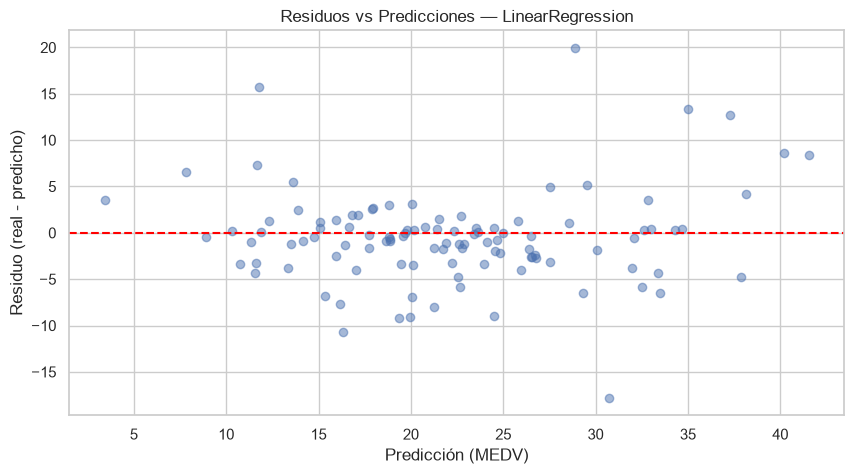

In [49]:
# grafico de residuos
residuos = y_test - pred_test

plt.figure(figsize=(10, 5))
plt.scatter(pred_test, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicción (MEDV)')
plt.ylabel('Residuo (real - predicho)')
plt.title('Residuos vs Predicciones — LinearRegression')
plt.show()

Los residuos se encuentran dispersos alrededor de cero, aunque se puede observar una mayor concentracion de valores negativos en algunas partes del grafico. Los residuos por debajo de la linea del cero indican una sobreestimacion del modelo, mientras que los que se encuentran sobre cero presentan una subestimacion. Junto a esto, observamos algunos valores muy elevados, lo que indica que existen casos donde el modelo presenta errores considerablemente mas grandes

## 4.2 Métodos de gradiente descendente

Elegimos hacer Gradiente decendiente y no el estocástico ni el mini batch ya que con el gradiente decendiente común es suficiente. Esas otras varaintes pueden ser mejor para datasets más grandes. Además, el estocástico y el mini batch meten ruido en la curva de pérdida vs época.

In [50]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100, plot=True):
    """
    Entrena un modelo de regresión lineal mediante Gradient Descent.
    Ajusta los pesos W de un modelo lineal y_pred = X @ W usando el
    Error Cuadrático Medio (MSE) como función de costo.

    plot=False evita graficar (se usa en la búsqueda de hiperparámetros del punto 5,
    donde se entrena muchas veces y no tiene sentido dibujar cada corrida).

    Retorna
    -------
    np.ndarray
        Vector de pesos W, forma (m + 1, 1), incluyendo el bias.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Columna de unos para el bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    # Inicializar pesos aleatorios
    W = np.random.randn(m + 1).reshape(m + 1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2 / n * grad_sum
        gradient = np.transpose(grad_mul).reshape(-1, 1)
        W = W - (lr * gradient)

    if not plot:
        return W

    # Gráfico de loss vs epochs
    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de validación')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    plt.show()

    return W


In [51]:
X_train_np = X_train_scaled.to_numpy()
X_test_np = X_test_scaled.to_numpy()
y_train_np = y_train.to_numpy().reshape(-1, 1)
y_test_np = y_test.to_numpy().reshape(-1, 1)

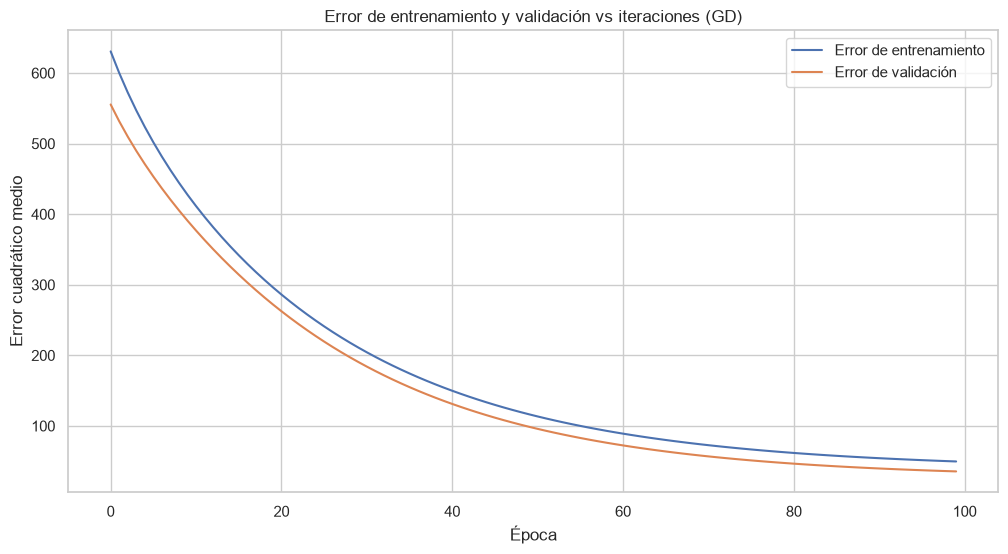

In [52]:
# Se usan los hiperparámetros por defecto de la función, sin ajustar nada todavía
# se hace en el punto 5.
np.random.seed(RANDOM_STATE) 
W_gd = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.01, epochs=100)

In [53]:
print(W_gd)
# Estos son los pesos que apendió el modelo, el primero es el bias (el precio base cuando todas 
# las varaibles estan en su promedio porque estan estandarizadas)
# 
# los otros son los coeficientes de cada varaible

[[20.06023587]
 [ 0.42219508]
 [ 1.15128187]
 [ 0.48127919]
 [-0.16709323]
 [ 3.00141524]
 [-0.21284395]
 [-0.27519897]
 [-0.18293016]
 [-0.64145319]
 [-1.86887814]
 [ 0.57915336]
 [-2.61115742]
 [ 1.25441553]]


In [54]:
X_train_b = np.hstack([np.ones((X_train_np.shape[0], 1)), X_train_np])
X_test_b = np.hstack([np.ones((X_test_np.shape[0], 1)), X_test_np])
pred_train_gd = (X_train_b @ W_gd).ravel()
pred_test_gd = (X_test_b @ W_gd).ravel()

print('Métricas de train (Gradient Descent)')
print('R²:', round(metrics.r2_score(y_train, pred_train_gd), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_gd)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train_gd), 4))

print('Métricas de test (Gradient Descent)')
print('R²:', round(metrics.r2_score(y_test, pred_test_gd), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_gd)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test_gd), 4))

Métricas de train (Gradient Descent)
R²: 0.4508
RMSE: 7.016
MAE: 4.5272
Métricas de test (Gradient Descent)
R²: 0.6032
RMSE: 5.9309
MAE: 3.9425


In [55]:
comparacion = pd.DataFrame({
    'Variable': ['bias'] + cols_numericas + [col_categorica],
    'GD': W_gd.ravel().round(3),
    'LinearRegression': [round(modelo_lr.intercept_, 3)] + list(modelo_lr.coef_.round(3))
})

comparacion['Diferencia'] = (comparacion['GD'] - comparacion['LinearRegression']).round(3)

comparacion

,Variable,GD,LinearRegression,Diferencia
0,bias,20.060,23.051,-2.991
1,CRIM,0.422,1.982,-1.560
2,ZN,1.151,1.086,0.065
3,INDUS,0.481,-0.070,0.551
4,NOX,-0.167,-0.102,-0.065
5,RM,3.001,3.130,-0.129
6,AGE,-0.213,-2.118,1.905
7,DIS,-0.275,-2.820,2.545
8,RAD,-0.183,0.474,-0.657
9,TAX,-0.641,-2.480,1.839


- Con los hiperparámetros por defecto (lr=0.01, epochs=100), el gradiente
descendiente no llega a converger
- el R² de test da ≈0.6032, peor que LinearRegression (≈0.7094), y el gráfico de loss vs epochs
muestra que la curva de loss todavía está bajando cuando se corta en la
época 100
- Los pesos difieren de LinearRegression

Esto sugiere que lr=0.01 es demasiado chico y/o epochs=100 es insuficiente para esa tasa de aprendizaje (lr).

En el punto 5 se explora un barrido de hiperparámetros, primero a mano y después de forma más formal con validación cruzada.


## 4.3 Métodos de regularización (Ridge, Lasso, Elastic Net)

- Probamos los tres métodos de regularización, con un alpha elegido a mano.  

- Usamos X_train_scaled (x train escalado) porque estos métodos penalizan la magnitud de los coeficientes y eso es comparable entre variables solo si están en la misma escala.

In [56]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# alpha elegido a mano
lasso = Lasso(alpha=0.01)
ridge = Ridge(alpha=0.1)
elasticnet = ElasticNet(alpha=0.01, l1_ratio=0.5)

lasso.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
elasticnet.fit(X_train_scaled, y_train)

print('Ridge score (train):', ridge.score(X_train_scaled, y_train))
print('Lasso score (train):', lasso.score(X_train_scaled, y_train))
print('ElasticNet score (train):', elasticnet.score(X_train_scaled, y_train))

Ridge score (train): 0.5951482140628808
Lasso score (train): 0.5951080370088586
ElasticNet score (train): 0.5950682107001117


Con los alphas elegidos a mano (0.01/0.1), los tres modelos dan un
resultado muy similar a LinearRegression (R²=0.5951 en train).


In [57]:
comparacion_coefs = pd.DataFrame({
    'Variable': cols_numericas + [col_categorica],
    'Ridge': ridge.coef_.round(3),
    'Lasso': lasso.coef_.round(3),
    'ElasticNet': elasticnet.coef_.round(3),
    'LinearRegression': modelo_lr.coef_.round(3)
})
comparacion_coefs

,Variable,Ridge,Lasso,ElasticNet,LinearRegression
0,CRIM,1.979,1.929,1.899,1.982
1,ZN,1.085,1.073,1.068,1.086
2,INDUS,-0.070,-0.066,-0.083,-0.070
3,NOX,-0.101,-0.062,-0.065,-0.102
4,RM,3.130,3.130,3.120,3.130
5,AGE,-2.117,-2.093,-2.071,-2.118
6,DIS,-2.817,-2.752,-2.719,-2.820
7,RAD,0.473,0.424,0.427,0.474
8,TAX,-2.476,-2.406,-2.366,-2.480
9,PTRATIO,-1.523,-1.512,-1.520,-1.523


Con estos alphas (chicos), los coeficientes de los tres modelos regularizados
son muy parecidos a los de LinearRegression, la penalización es leve.  

Lasso no descartó ninguna variable (ningún coeficiente en 0), lo cual es
esperable con un alpha tan chico como 0.01.

## 4.4 Obtener las métricas adecuadas tanto para entrenamiento como para prueba.

**Métricas elegidas: R², RMSE y MAE.**

- **R²** indica qué proporción de la variabilidad de MEDV explica el modelo, es más directa para responder si es buen fitting.
- **RMSE** penaliza más los errores grandes (por el cuadrado)
- **MAE** es más robusto a outliers. 
- Comparar ambas permite detectar si hay pocas predicciones malas dominando el error (si RMSE >> MAE, es señal de eso).

**Se descartan MSE y MAPE:**
- **MSE** da la misma información que RMSE pero en unidades al cuadrado, menos interpretable.
- **MAPE** pondera los errores en términos porcentuales. Un mismo error en dólares pesa más porcentualmente en las casas baratas que en las caras.

In [58]:
def calcular_metricas(y_true, y_pred):
    r2 = metrics.r2_score(y_true, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    mae = metrics.mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

# Predicciones ya calculadas
modelos_pred = {
    'LinearRegression': (pred_train, pred_test),
    'Gradient Descent': (pred_train_gd, pred_test_gd),
    'Ridge': (ridge.predict(X_train_scaled), ridge.predict(X_test_scaled)),
    'Lasso': (lasso.predict(X_train_scaled), lasso.predict(X_test_scaled)),
    'ElasticNet': (elasticnet.predict(X_train_scaled), elasticnet.predict(X_test_scaled)),
}

filas = []
for nombre, (pt, pte) in modelos_pred.items():
    r2_tr, rmse_tr, mae_tr = calcular_metricas(y_train, pt)
    r2_te, rmse_te, mae_te = calcular_metricas(y_test, pte)
    filas.append({
        'Modelo': nombre,
        'R² train': round(r2_tr, 4), 'R² test': round(r2_te, 4),
        'RMSE train': round(rmse_tr, 4), 'RMSE test': round(rmse_te, 4),
        'MAE train': round(mae_tr, 4), 'MAE test': round(mae_te, 4),
    })

df_metricas = pd.DataFrame(filas)
df_metricas

,Modelo,R² train,R² test,RMSE train,RMSE test,MAE train,MAE test
0,LinearRegression,0.5951,0.7094,6.0240,5.0751,4.0486,3.3820
1,Gradient Descent,0.4508,0.6032,7.0160,5.9309,4.5272,3.9425
2,Ridge,0.5951,0.7094,6.0241,5.0750,4.0484,3.3818
3,Lasso,0.5951,0.7097,6.0243,5.0728,4.0477,3.3819
4,ElasticNet,0.5951,0.7098,6.0246,5.0717,4.0456,3.3790


La métrica de train sola no dice si el modelo generaliza
- un modelo puede ajustar perfecto los datos que ya vio y fallar con datos nuevos (overfitting).

- **Train ≈ Test:** el modelo generaliza bien.
- **Train >> Test:** señal de overfitting, el modelo memorizó el ruido de entrenamiento.
- **Ambas malas:** underfitting, el modelo es demasiado simple para el problema.

En este caso, la similitud entre train y test en LinearRegression, Ridge, Lasso y ElasticNet confirma que no hay overfitting.

Gradient Descent es la excepción en esta tabla porque corresponde a la versión sin optimizar de GD (lr=0.01).


## 5.1 Variar los hiperparámetros de gradiente descendente.

En 4.2 usamos los valores por defecto (lr=0.01, epochs=100) que no llegaban a converger (R² test≈0.6032). Acá probamos primero manualmente otras combinaciones para ver el efecto de cada hiperparámetro y, al final, elegimos lr y epochs de forma más formal con validación cruzada dentro de train, sin mirar test.


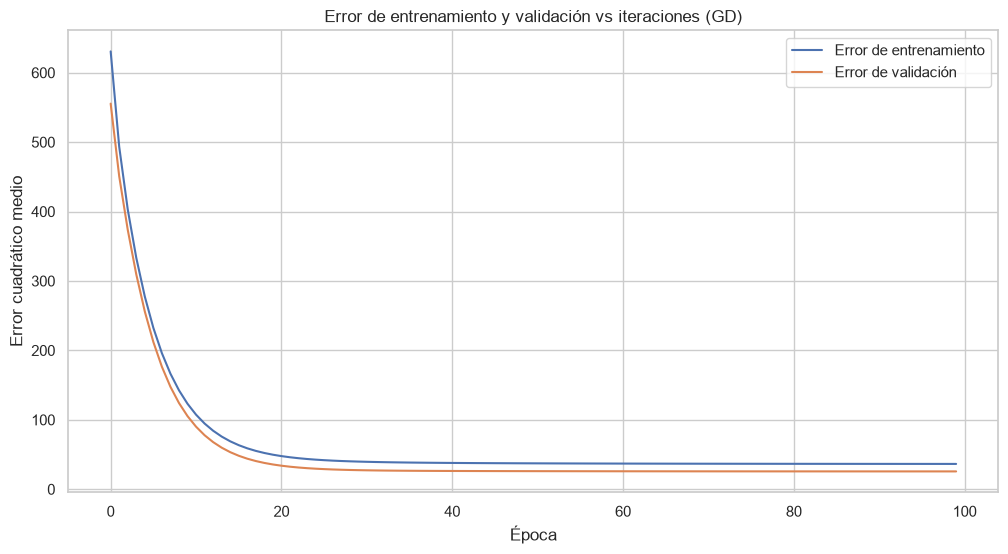

lr=0.05, epochs=100 | R² test: 0.7106


In [59]:
# Intento 1: subimos lr
np.random.seed(RANDOM_STATE) 
W_prueba1 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.05, epochs=100)
pred_test_prueba1 = (X_test_b @ W_prueba1).ravel()
print('lr=0.05, epochs=100 | R² test:', round(metrics.r2_score(y_test, pred_test_prueba1), 4))

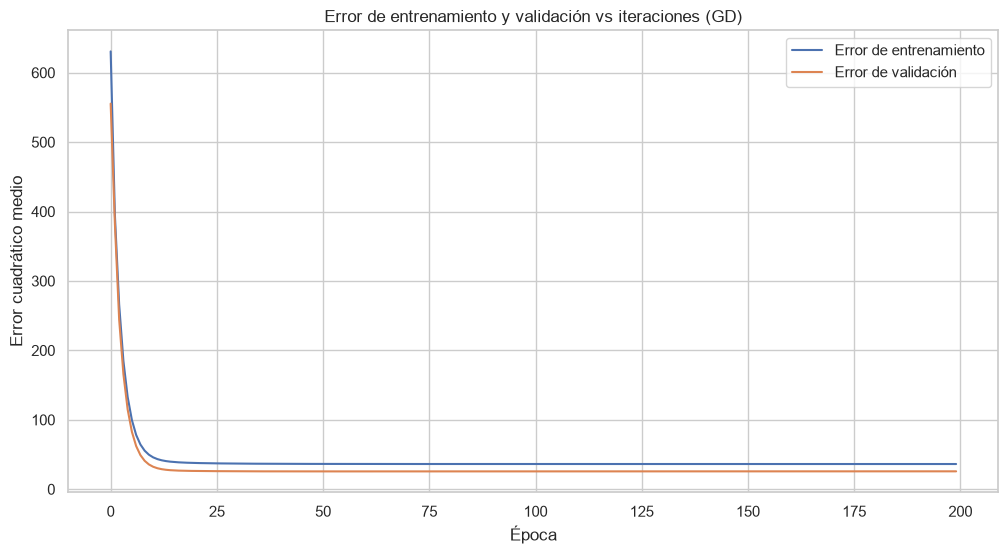

lr=0.1, epochs=200 | R² test: 0.7094


In [60]:
# Intento 2: lr más alto, más epochs
np.random.seed(RANDOM_STATE) 
W_prueba2 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.1, epochs=200)
pred_test_prueba2 = (X_test_b @ W_prueba2).ravel()
print('lr=0.1, epochs=200 | R² test:', round(metrics.r2_score(y_test, pred_test_prueba2), 4))

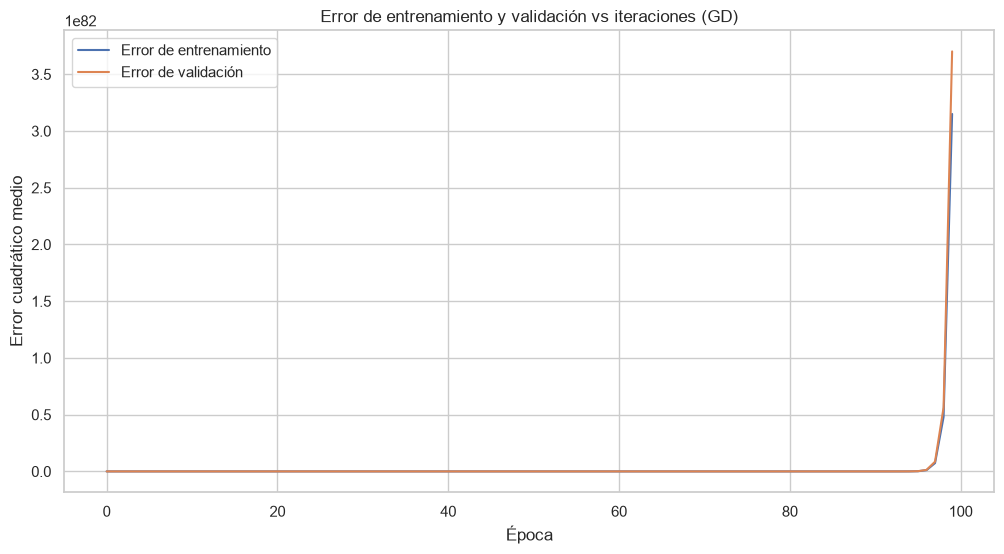

lr=0.3, epochs=100 | R² test: -2.742274443509796e+81


In [61]:
# Intento 3: lr demasiado alto
np.random.seed(RANDOM_STATE) 
W_prueba3 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.3, epochs=100)
pred_test_prueba3 = (X_test_b @ W_prueba3).ravel()
print('lr=0.3, epochs=100 | R² test:', metrics.r2_score(y_test, pred_test_prueba3))

Subir el lr mejora la convergencia:
- con lr=0.05 el R² de test ya se acerca bastante al de LinearRegression (0.7106 contra 0.7094)
- con lr=0.1 el R² de test prácticamente iguala al de LinearRegression (0.7094)
- pasado cierto punto (lr=0.3), el modelo **diverge** en vez de mejorar: los pasos son demasiado grandes y el error explota en vez de bajar.


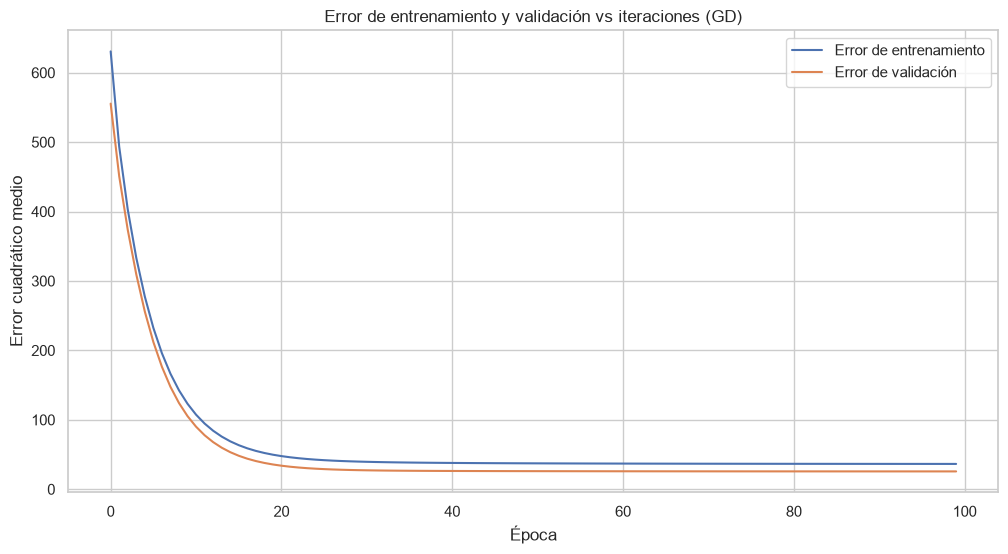

In [62]:
# elegimos lr=0.05 epochs=100
np.random.seed(RANDOM_STATE)
W_gd = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.05, epochs=100)


In [63]:
comparacion = pd.DataFrame({
    'Variable': ['bias'] + cols_numericas + [col_categorica],
    'GD': W_gd.ravel().round(3),
    'LinearRegression': [round(modelo_lr.intercept_, 3)] + list(modelo_lr.coef_.round(3))
})

comparacion['Diferencia'] = (comparacion['GD'] - comparacion['LinearRegression']).round(3)

comparacion

,Variable,GD,LinearRegression,Diferencia
0,bias,23.051,23.051,0.000
1,CRIM,1.676,1.982,-0.306
2,ZN,0.996,1.086,-0.090
3,INDUS,-0.093,-0.070,-0.023
4,NOX,0.025,-0.102,0.127
5,RM,3.121,3.130,-0.009
6,AGE,-1.846,-2.118,0.272
7,DIS,-2.309,-2.820,0.511
8,RAD,0.310,0.474,-0.164
9,TAX,-1.929,-2.480,0.551


Con lr=0.05 las métricas de GD a 100 épocas ya están cerca de LinearRegression (R² test=0.7106 contra 0.7094), pero la tabla de pesos muestra que varios coeficientes todavía están lejos del valor de LinearRegression, sobre todo en variables correlacionadas entre sí (RAD, TAX).


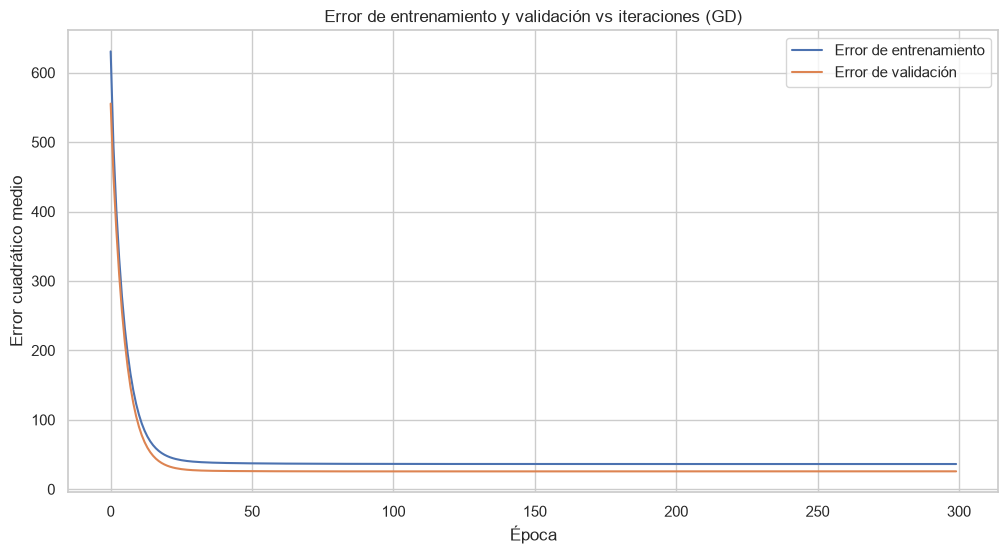

In [64]:
# aumento epocas = 300
np.random.seed(RANDOM_STATE)
W_gd_300 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.05, epochs=300)

In [65]:
comparacion_300 = pd.DataFrame({
    'Variable': ['bias'] + cols_numericas + [col_categorica],
    'GD (300 epochs)': W_gd_300.ravel().round(3),
    'LinearRegression': [round(modelo_lr.intercept_, 3)] + list(modelo_lr.coef_.round(3))
})
comparacion_300['Diferencia'] = (comparacion_300['GD (300 epochs)'] - comparacion_300['LinearRegression']).round(3)
comparacion_300

,Variable,GD (300 epochs),LinearRegression,Diferencia
0,bias,23.051,23.051,0.000
1,CRIM,1.979,1.982,-0.003
2,ZN,1.082,1.086,-0.004
3,INDUS,-0.085,-0.070,-0.015
4,NOX,-0.095,-0.102,0.007
5,RM,3.129,3.130,-0.001
6,AGE,-2.115,-2.118,0.003
7,DIS,-2.812,-2.820,0.008
8,RAD,0.446,0.474,-0.028
9,TAX,-2.439,-2.480,0.041


In [66]:
pred_test_300 = (X_test_b @ W_gd_300).ravel()
print('GD (300 epochs) | R² test:', round(metrics.r2_score(y_test, pred_test_300), 4))

GD (300 epochs) | R² test: 0.7094


mientras que con 300 épocas esas diferencias se reducen.
- Esto es coherente con que la colinealidad entre variables (RAD-TAX, r = 0.88) genera una zona relativamente "plana" en la función de costo: las predicciones ya son buenas con pocas épocas, pero los pesos individuales necesitan más iteraciones para asentarse en el mismo punto que la solución analítica (regresión lineal).
- Esto **no** es lo que explica que GD diverja con lr=0.3: eso ocurre porque ese lr es demasiado alto y hace que los pasos de la actualización sean demasiado grandes, sin importar la colinealidad.


### Selección final de lr y epochs con K-Fold (sin mirar test)

Las pruebas anteriores eligieron lr y epochs mirando el R² de test, lo cual es una fuga de información: se estaría usando el conjunto de evaluación para tomar una decisión de diseño del modelo. Para evitarlo, se prueba una grilla de combinaciones con `KFold(5)` **dentro de train** (mismo criterio que se usa más abajo para elegir el alpha de Ridge/Lasso/ElasticNet) y se elige la que da menor MSE de validación promedio. Recién al final se entrena con todo train y se evalúa en test, una única vez.

Nota sobre la métrica usada acá: para elegir entre combinaciones de hiperparámetros se usa MSE, no las métricas R², RMSE, MAE. 
- MSE es la función de costo que el propio `gradient_descent` minimiza en cada paso así que usarla para comparar candidatos es coherente y es el mismo criterio que usan por defecto `RidgeCV`/`LassoCV`/`ElasticNetCV` más abajo. Además, como RMSE es la raíz cuadrada de MSE (una función creciente), elegir por MSE o por RMSE es lo mismo. R², RMSE y MAE siguen siendo las métricas para reportar y comparar los modelos ya entrenados, MSE se usa acá solo como criterio interno de búsqueda.


In [67]:
from sklearn.model_selection import KFold

def mse_pesos(W, X, y):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    pred = Xb @ W
    return np.mean((y - pred) ** 2) if np.all(np.isfinite(pred)) else np.inf  # inf si el GD divergio

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grilla_gd = []
for lr in [0.01, 0.05, 0.1, 0.3]:
    for epochs in [100, 200, 300, 500]:
        mse_folds = []
        for idx_tr, idx_val in kf.split(X_train_np):
            np.random.seed(RANDOM_STATE)
            W = gradient_descent(X_train_np[idx_tr], y_train_np[idx_tr],
                                  X_train_np[idx_val], y_train_np[idx_val],
                                  lr=lr, epochs=epochs, plot=False)
            mse_folds.append(mse_pesos(W, X_train_np[idx_val], y_train_np[idx_val]))
        grilla_gd.append({'lr': lr, 'epochs': epochs, 'MSE val (prom. 5 folds)': np.mean(mse_folds)})

df_grilla_gd = pd.DataFrame(grilla_gd).sort_values('MSE val (prom. 5 folds)').reset_index(drop=True)
mejor_lr = float(df_grilla_gd.loc[0, 'lr'])
mejor_epochs = int(df_grilla_gd.loc[0, 'epochs'])
print(f'Mejores hiperparámetros según MSE de validación (5 folds): lr={mejor_lr}, epochs={mejor_epochs}')
df_grilla_gd


Mejores hiperparámetros según MSE de validación (5 folds): lr=0.01, epochs=300


,lr,epochs,MSE val (prom. 5 folds)
0,0.01,300,4.361692e+01
1,0.01,200,4.395518e+01
2,0.01,500,4.400433e+01
3,0.05,100,4.401163e+01
4,0.05,200,4.468918e+01
5,0.10,100,4.469430e+01
6,0.05,300,4.485291e+01
7,0.10,200,4.488966e+01
8,0.05,500,4.489762e+01
9,0.10,300,4.489975e+01


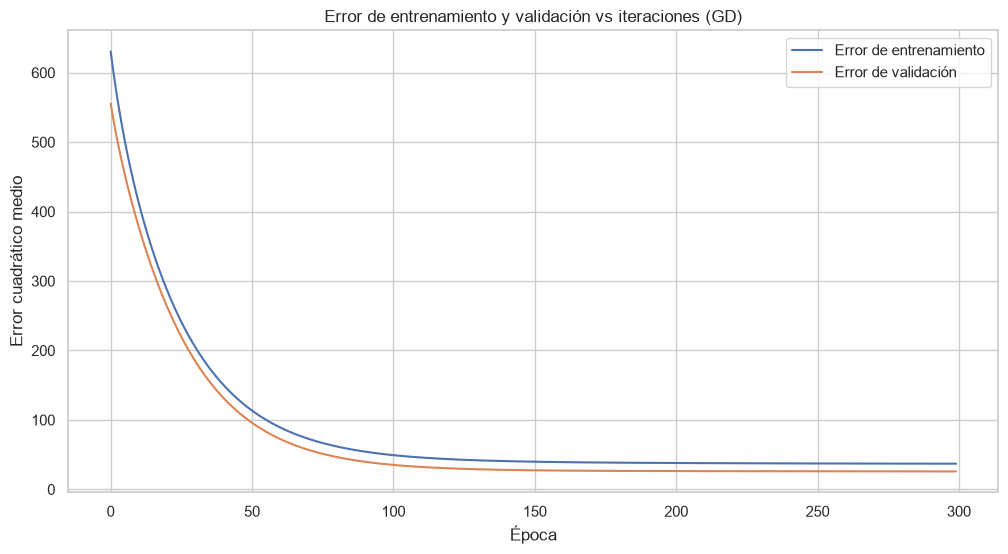

Gradient Descent optimizado (lr=0.01, epochs=300)
R² train: 0.5879 | R² test: 0.7085
RMSE train: 6.0777 | RMSE test: 5.0832


In [68]:
# Con lr y epochs elegidos solo con train/val, se entrena sobre todo train y se evalúa en test una única vez.

np.random.seed(RANDOM_STATE)
W_gd = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=mejor_lr, epochs=mejor_epochs)

pred_train_gd = (X_train_b @ W_gd).ravel()
pred_test_gd = (X_test_b @ W_gd).ravel()

print(f'Gradient Descent optimizado (lr={mejor_lr}, epochs={mejor_epochs})')
print('R² train:', round(metrics.r2_score(y_train, pred_train_gd), 4), '| R² test:', round(metrics.r2_score(y_test, pred_test_gd), 4))
print('RMSE train:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_gd)), 4), '| RMSE test:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_gd)), 4))


Se eligió `lr=0.01` y `epochs=300`, la combinación con menor MSE de validación promedio dentro de train. Entrenando con todo train y evaluando en test se obtiene R²=0.7085 y RMSE=5.0832, muy similar a LinearRegression (R²=0.7094, RMSE=5.0751). A diferencia de las pruebas manuales, esta elección no miró el conjunto de test.


## 5.2 Variar los hiperparámetros de Lasso y Ridge

En 4.3 usamos alphas elegidos a mano y chicos (Ridge=0.1, Lasso=0.01), que dieron
un resultado muy similar a LinearRegression. Acá probamos manualmente otros
valores, más grandes, para ver si el modelo mejora o empeora, y al final se elige
el alpha final de cada modelo con validación cruzada dentro de train, sin mirar test.


In [69]:
# Intento 1 (Ridge): alpha más alto
ridge_prueba1 = Ridge(alpha=1)
ridge_prueba1.fit(X_train_scaled, y_train)
pred_test_ridge1 = ridge_prueba1.predict(X_test_scaled)
print('Ridge alpha=1 | R² test:', round(metrics.r2_score(y_test, pred_test_ridge1), 4))

Ridge alpha=1 | R² test: 0.7096


In [70]:
# Intento 2 (Ridge): alpha bastante más alto
ridge_prueba2 = Ridge(alpha=10)
ridge_prueba2.fit(X_train_scaled, y_train)
pred_test_ridge2 = ridge_prueba2.predict(X_test_scaled)
print('Ridge alpha=10 | R² test:', round(metrics.r2_score(y_test, pred_test_ridge2), 4))

Ridge alpha=10 | R² test: 0.7101


In [71]:
# Intento 3 (Ridge): alpha bastante más alto todavía
ridge_prueba3 = Ridge(alpha=50)
ridge_prueba3.fit(X_train_scaled, y_train)
pred_test_ridge3 = ridge_prueba3.predict(X_test_scaled)
print('Ridge alpha=50 | R² test:', round(metrics.r2_score(y_test, pred_test_ridge3), 4))

Ridge alpha=50 | R² test: 0.7055


In [72]:
# Intento 1 (Lasso): alpha más alto
lasso_prueba1 = Lasso(alpha=0.05)
lasso_prueba1.fit(X_train_scaled, y_train)
pred_test_lasso1 = lasso_prueba1.predict(X_test_scaled)
print('Lasso alpha=0.05 | R² test:', round(metrics.r2_score(y_test, pred_test_lasso1), 4),
      '| variables descartadas:', (lasso_prueba1.coef_ == 0).sum())

Lasso alpha=0.05 | R² test: 0.7099 | variables descartadas: 1


In [73]:
# Intento 2 (Lasso): alpha demasiado alto
lasso_prueba3 = Lasso(alpha=1)
lasso_prueba3.fit(X_train_scaled, y_train)
pred_test_lasso3 = lasso_prueba3.predict(X_test_scaled)
print('Lasso alpha=1 | R² test:', round(metrics.r2_score(y_test, pred_test_lasso3), 4),
      '| variables descartadas:', (lasso_prueba3.coef_ == 0).sum())


Lasso alpha=1 | R² test: 0.6465 | variables descartadas: 6


Subir el alpha no empeora demasiado el modelo dentro del rango probado: tanto Ridge como Lasso se mantienen cerca de LinearRegression hasta cierto punto.

Pasado ese punto empiezan a empeorar:
- en Lasso empieza a descartar variables que sí aportaban información, cada vez más cerca del underfitting a medida que sube el alpha.
- Ridge nunca descarta variables, solo achica los coeficientes.

En vez de quedarnos con el mejor de estos intentos manuales (que estaría eligiendo el alpha mirando el R² de test), a continuación se elige el alpha final de Ridge, Lasso y ElasticNet con validación cruzada dentro de train.


### Selección final de alpha con validación cruzada (sin mirar test)

Se usa `RidgeCV`, `LassoCV` y `ElasticNetCV` con `cv=5`: cada uno prueba una grilla de valores de alpha usando solo train (dividido internamente en 5 folds) y se queda con el que da menor error de validación. Es el mismo criterio que se usó para lr y epochs de Gradient Descent en 5.1, y evita que el alpha se elija mirando el R² de test.


In [74]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

ridgeCV = RidgeCV(alphas=np.logspace(-2, 3, 60), cv=5)
lassoCV = LassoCV(cv=5, random_state=RANDOM_STATE)
elasticnetCV = ElasticNetCV(cv=5, random_state=RANDOM_STATE)

ridgeCV.fit(X_train_scaled, y_train)
lassoCV.fit(X_train_scaled, y_train)
elasticnetCV.fit(X_train_scaled, y_train)

print('Alpha elegido - Ridge:', round(ridgeCV.alpha_, 4))
print('Alpha elegido - Lasso:', round(lassoCV.alpha_, 4))
print('Alpha elegido - ElasticNet:', round(elasticnetCV.alpha_, 4))

# Nos quedamos con los modelos elegidos por validación cruzada
ridge = ridgeCV
lasso = lassoCV
elasticnet = elasticnetCV

print('R² test - Ridge:', round(ridge.score(X_test_scaled, y_test), 4))
print('R² test - Lasso:', round(lasso.score(X_test_scaled, y_test), 4))
print('R² test - ElasticNet:', round(elasticnet.score(X_test_scaled, y_test), 4))


Alpha elegido - Ridge: 44.0624
Alpha elegido - Lasso: 0.1482
Alpha elegido - ElasticNet: 0.1475
R² test - Ridge: 0.7065
R² test - Lasso: 0.7085
R² test - ElasticNet: 0.7054


Ridge eligió alpha≈44.0624, Lasso alpha≈0.1482 y ElasticNet alpha≈0.1475. En test, Ridge da R²=0.7065, Lasso R²=0.7085 y ElasticNet R²=0.7054, los tres cerca del 0.7094 de LinearRegression: la regularización no cambia mucho el resultado en este caso.


### Por qué Lasso descarta RAD y no TAX?

RAD y TAX están muy correlacionadas entre sí (r = 0.88). Cada modelo maneja la colinealidad de forma distinta:

- En **LinearRegression**, sin penalización, el coeficiente de RAD sale positivo (+0.474) y el de TAX negativo (-2.480), el modelo reparte el peso de forma inestable.
- En **Ridge**, las dos se achican pero las dos se mantienen (RAD: +0.233, TAX: -1.535): Ridge reparte la penalización entre variables correlacionadas, no elige.
- En **Lasso**, RAD queda directamente en **0** y casi todo el peso pasa a TAX (-1.501, casi igual al de Ridge): entre dos variables muy correlacionadas, Lasso tiende a quedarse con una y descartar la otra en vez de repartir.

Como Lasso ya hace ese descarte automáticamente, no hace falta repetirlo a mano para reproducir su resultado. 

- Pero elejimos comparar con un modelo de regresión lineal sin penalización qué tan distinto es sacar RAD contra sacar TAX:

In [75]:
# Comparación: LinearRegression con todas las variables vs sacando RAD vs sacando TAX
cols_sin_rad = [c for c in X_train_scaled.columns if c != 'RAD']
cols_sin_tax = [c for c in X_train_scaled.columns if c != 'TAX']

lr_sin_rad = LinearRegression().fit(X_train_scaled[cols_sin_rad], y_train)
lr_sin_tax = LinearRegression().fit(X_train_scaled[cols_sin_tax], y_train)

comparacion_rad_tax = pd.DataFrame({
    'Variables': ['Todas', 'Sin RAD', 'Sin TAX'],
    'R² test': [
        round(modelo_lr.score(X_test_scaled, y_test), 4),
        round(lr_sin_rad.score(X_test_scaled[cols_sin_rad], y_test), 4),
        round(lr_sin_tax.score(X_test_scaled[cols_sin_tax], y_test), 4),
    ],
    'Coef. TAX': [
        round(modelo_lr.coef_[list(X_train_scaled.columns).index('TAX')], 3),
        round(lr_sin_rad.coef_[cols_sin_rad.index('TAX')], 3),
        None,
    ],
    'Coef. RAD': [
        round(modelo_lr.coef_[list(X_train_scaled.columns).index('RAD')], 3),
        None,
        round(lr_sin_tax.coef_[cols_sin_tax.index('RAD')], 3),
    ],
})
comparacion_rad_tax


,Variables,R² test,Coef. TAX,Coef. RAD
0,Todas,0.7094,-2.480,0.474
1,Sin RAD,0.7061,-2.173,NaN
2,Sin TAX,0.6949,NaN,-0.986


- Sacar cualquiera de las dos cambia poco el R² de test (0.7094 con todas, 0.7061 sin RAD, 0.6949 sin TAX), 

- Pero cambia mucho el coeficiente de la que queda:

 - **RAD**: con TAX en el modelo, su coeficiente es **+0.474**, sin TAX pasa a **-0.986**, cambia de signo por completo. Esto confirma que el problema es de interpretación de los coeficientes: el modelo predice igual de bien, pero el coeficiente de la que queda ya no representa lo mismo cuando se saca a la otra.


## 6. Comparación de modelos

Se comparan los 5 modelos usando las métricas R², RMSE, MAE, calculadas sobre test.

Se usan las versiones finales de cada modelo:
- LinearRegression (4.1)
- Gradient Descent con lr y epochs elegidos por K-Fold (5.1)
- Ridge/Lasso/ElasticNet con los alphas elegidos por K-Folds (5.2)


In [76]:
# Predicciones de cada modelo despues del ajuste de hiperparámetros
modelos_finales = {
    'LinearRegression': (pred_train, pred_test),
    'Gradient Descent': (pred_train_gd, pred_test_gd),
    'Ridge': (ridge.predict(X_train_scaled), ridge.predict(X_test_scaled)),
    'Lasso': (lasso.predict(X_train_scaled), lasso.predict(X_test_scaled)),
    'ElasticNet': (elasticnet.predict(X_train_scaled), elasticnet.predict(X_test_scaled)),
}

filas = []
for nombre, (pt, pte) in modelos_finales.items():
    r2_tr, rmse_tr, mae_tr = calcular_metricas(y_train, pt)
    r2_te, rmse_te, mae_te = calcular_metricas(y_test, pte)
    filas.append({
        'Modelo': nombre,
        'R² train': round(r2_tr, 4), 'R² test': round(r2_te, 4),
        'RMSE train': round(rmse_tr, 4), 'RMSE test': round(rmse_te, 4),
        'MAE train': round(mae_tr, 4), 'MAE test': round(mae_te, 4),
    })

df_comparacion_final = pd.DataFrame(filas).sort_values('RMSE test')
df_comparacion_final

,Modelo,R² train,R² test,RMSE train,RMSE test,MAE train,MAE test
0,LinearRegression,0.5951,0.7094,6.0240,5.0751,4.0486,3.3820
1,Gradient Descent,0.5879,0.7085,6.0777,5.0832,4.0364,3.3707
3,Lasso,0.5885,0.7085,6.0731,5.0835,4.0539,3.3798
2,Ridge,0.5873,0.7065,6.0819,5.1002,4.0549,3.3827
4,ElasticNet,0.5853,0.7054,6.0965,5.1100,4.0665,3.3833


Métrica para comparar: RMSE de test, es más directa para ver cuál se equivoca menos en promedio.

El mejor modelo por RMSE de test es **LinearRegression** (RMSE=5.0751, R²=0.7094). Las diferencias entre los cinco modelos son chicas: el RMSE de test va de 5.0751 a 5.1100, una diferencia de solo 0.0349. Esa diferencia es menor que la variabilidad que introduce la propia partición train/test (ver la sección siguiente), por lo que no alcanza para afirmar que un modelo sea claramente mejor que los demás.


### Variabilidad de la partición train/test

Para dimensionar cuánto depende el R² de la partición usada (y no solo del modelo), se corre una validación cruzada de 5 folds sobre train con LinearRegression, sin tocar test.


In [77]:
from sklearn.model_selection import cross_val_score

kf_eval = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_cv_lr = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=kf_eval, scoring='r2')
print('R² por fold:', scores_cv_lr.round(3))
print(f'R² promedio: {scores_cv_lr.mean():.4f} ± {scores_cv_lr.std():.4f}')


R² por fold: [0.309 0.62  0.455 0.625 0.412]
R² promedio: 0.4842 ± 0.1225


El R² promedio en esta validación cruzada es 0.4842 ± 0.1225, con folds que van de 0.309 a 0.625. Esa variabilidad (mayor que la diferencia entre los cinco modelos de la tabla anterior) es la explicación de por qué el R² de test (0.7094) queda por encima del de train (0.5951), el resultado depende bastante de qué filas caen en cada partición.


In [78]:
# Repetimos el split con distintas semillas para ver cuánto cambia el R² de test (sin tocar el modelo)
r2_semillas = []
for seed in [42, 1, 2, 3, 4]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=X[col_categorica].fillna(-1))
    Xtr, Xte = Xtr.copy(), Xte.copy()
    sc_tmp = RobustScaler()
    tr_sc = pd.DataFrame(sc_tmp.fit_transform(Xtr[cols_numericas]), columns=cols_numericas, index=Xtr.index)
    te_sc = pd.DataFrame(sc_tmp.transform(Xte[cols_numericas]), columns=cols_numericas, index=Xte.index)
    imp = KNNImputer(n_neighbors=5)
    Xtr[cols_numericas] = sc_tmp.inverse_transform(imp.fit_transform(tr_sc))
    Xte[cols_numericas] = sc_tmp.inverse_transform(imp.transform(te_sc))
    chas_imp = SimpleImputer(strategy='most_frequent').fit(Xtr[['CHAS']])
    Xtr['CHAS'] = chas_imp.transform(Xtr[['CHAS']]).ravel(); Xte['CHAS'] = chas_imp.transform(Xte[['CHAS']]).ravel()
    for c in ['CRIM', 'DIS']:
        Xtr[c] = np.log1p(Xtr[c]); Xte[c] = np.log1p(Xte[c])
    ss_tmp = StandardScaler()
    r2_semillas.append(round(LinearRegression().fit(ss_tmp.fit_transform(Xtr), ytr).score(ss_tmp.transform(Xte), yte), 3))

print('R² test por semilla:', r2_semillas)
print(f'Promedio: {np.mean(r2_semillas):.3f} ± {np.std(r2_semillas):.3f}')


R² test por semilla: [0.709, 0.736, 0.471, 0.52, 0.545]
Promedio: 0.596 ± 0.106


Cambiar directamente la semilla del split (en vez de solo dentro de train) confirma lo mismo: el R² de test de LinearRegression varía bastante según qué filas caen en test, no solo según el modelo.


## 7. Conclusión


Sobre el preprocesamiento:

- El dataset presentó datos faltantes no aleatorios (asociados al perfil de la zona) y variables con sesgo marcado (CRIM, B), lo que llevó a imputar con KNN en vez de la media/mediana, y a aplicar log sobre CRIM y DIS.

- Se detectó una colinealidad alta entre RAD y TAX (r = 0.88). En este trabajo se decidió mantener ambas variables: eliminar cualquiera de las dos descarta información real, y en las pruebas  no se observó que sacarlas mejore las métricas de test. Esta colinealidad hace que los coeficientes de RAD y TAX sean menos estables (el gradiente descendiente tarda más iteraciones en asentarlos) y es una de las razones por las que la regularización es razonable para este problema. Que el gradiente descendiente diverja con lr=0.3 no se debe a la colinealidad, sino a que ese lr es demasiado alto y hace que los pasos sean demasiado grandes.


Sobre los modelos:

- LinearRegression y el gradiente descendiente con lr y epochs elegidos por K-Fold (lr=0.01, epochs=300, sin mirar test) llegan prácticamente al mismo resultado: R² test=0.7085 contra 0.7094 de LinearRegression.

- Para Ridge, Lasso y ElasticNet el alpha se eligió con validación cruzada de 5 folds dentro de train: 44.0624 para Ridge, 0.1482 para Lasso y 0.1475 para ElasticNet. Los tres dan un R² de test entre 0.7054 y 0.7085, similar al de LinearRegression (0.7094).

- Por RMSE de test, el mejor modelo es LinearRegression (5.0751), pero la diferencia con los demás (0.0349) es menor que la variabilidad entre particiones train/test que se midió en el punto 6.


Se consiguió un fitting moderado.

- Todos los modelos tienen un R² de train de aproximadamente 0.5951 y de test de aproximadamente 0.7094, sin señales de overfitting: la diferencia se explica porque, con este split, la partición de test resultó más favorable que la de train (la validación cruzada del punto 6 dio un R² promedio de 0.4842 ± 0.1225 dentro de train)

- Un R² de train de 0.5951 indica que todavía hay una parte importante de la variabilidad de MEDV que el modelo no logra explicar.Se observó que la relación entre LSTAT y MEDV es curva no lineal.
